In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
cd /Users/armandoroqueestrada/Proyecto_Proca/stability

/Users/armandoroqueestrada/Proyecto_Proca/Stability


In [3]:
import Modules.Background as bg
import numpy as np

import matplotlib.pyplot as plt
import Modules.Plot as cplot

In [4]:
cplot.general()

### Type of polarizations:

$i)$ $\gamma=0$, $\alpha=0$ if the polarization is linear, 

$ii)$ $\gamma=0$, $\alpha=1$ if the polarization is circular, and 

$iii)$ $\gamma=1$, $\alpha=0$ if the polarization is radial.


### Background solutions

Since we have scaling freedom, we only need to compute $\sigma_0 = 1$ and derive the rest from this.

\begin{align}
t \to \lambda_*^{-1} t, \quad \vec{x}\to \lambda_*^{-1/2} \vec{x},\quad U\to \lambda_x U, \quad \vec\psi \to \lambda_* \vec\psi
\end{align}

In [5]:
s0val = [0.001, 0.01, 0.05, 0.1, 0.5, 0.8, 1, 1.2, 1.4, 1.6, 1.8, 2, 2.2, 2.4, 2.6, 2.8, 3, 3.2, 3.4, 3.6, 3.8, 4, 4.2, 4.4, 4.6, 4.8, 5]

Finding a profile with nodes: [1]
Final precision: U0 = [0.02061579] radius 224.89849309666693


/Users/armandoroqueestrada/Proyecto_Proca/Stability/Modules/Plot/plot_conf.py:345: UserWarning: The py, pz ccomponents was off because the number of fields is 1
  warnings.warn("The py, pz ccomponents was off because the number of fields is %d"%numFields)


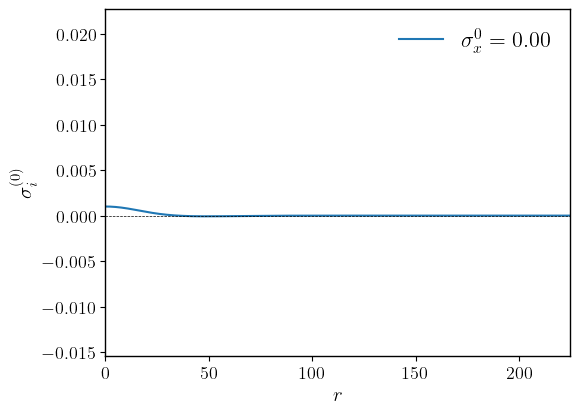

Finding a profile with nodes: [1]
Final precision: U0 = [0.09569] radius 109.50218114992128


/Users/armandoroqueestrada/Proyecto_Proca/Stability/Modules/Plot/plot_conf.py:345: UserWarning: The py, pz ccomponents was off because the number of fields is 1
  warnings.warn("The py, pz ccomponents was off because the number of fields is %d"%numFields)


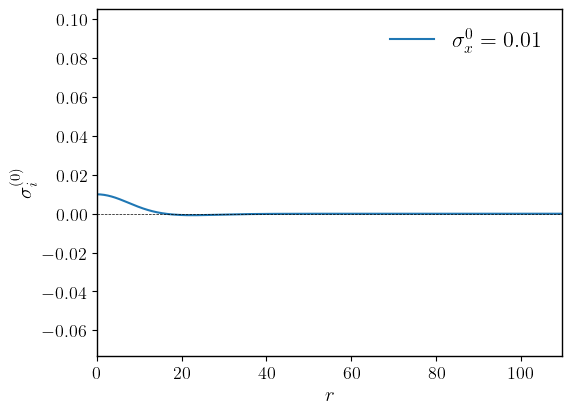

Finding a profile with nodes: [1]
Final precision: U0 = [0.27979926] radius 63.714791716217945


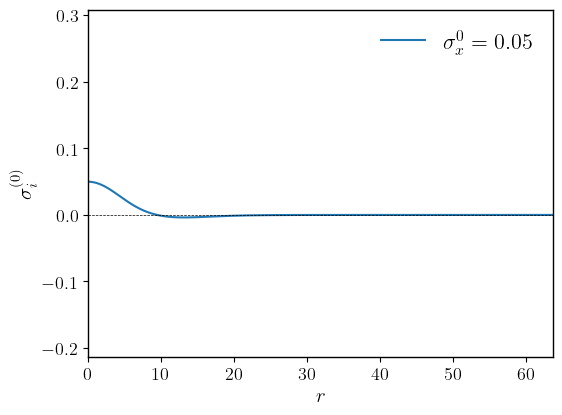

Finding a profile with nodes: [1]
Final precision: U0 = [0.44415364] radius 50.53522839221528


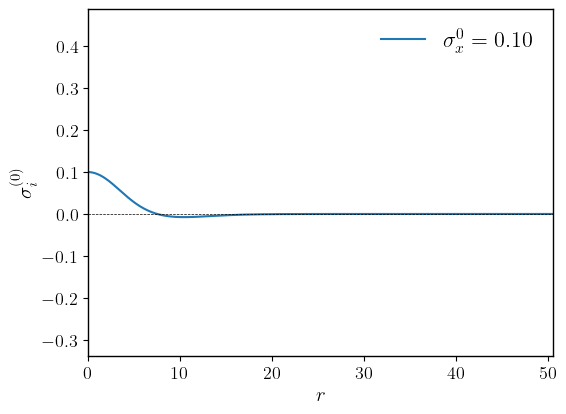

Finding a profile with nodes: [1]
Solution found: U0 = [1.29871313] radius 29.565160520880735


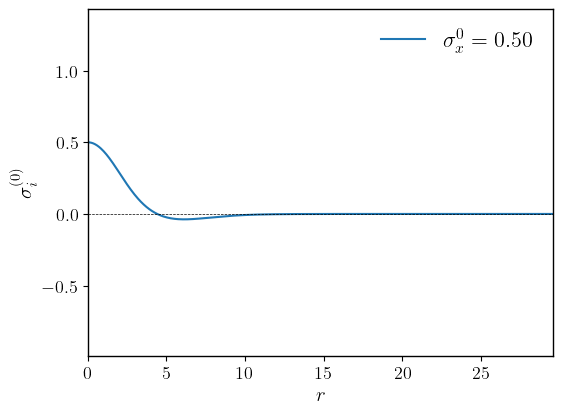

Finding a profile with nodes: [1]
Solution found: U0 = [1.77661457] radius 25.393536474664987


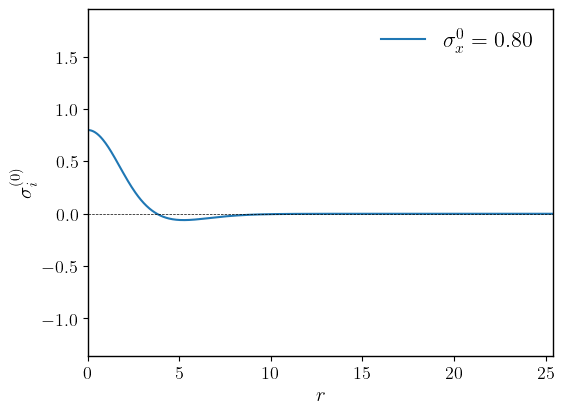

Finding a profile with nodes: [1]
Solution found: U0 = [2.06157859] radius 23.673360934081412


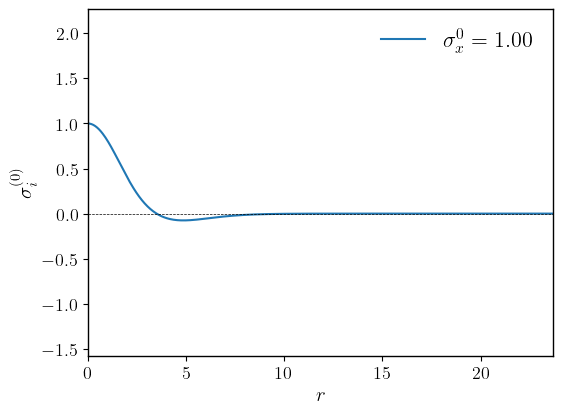

Finding a profile with nodes: [1]
Solution found: U0 = [2.32802368] radius 22.646069679232138


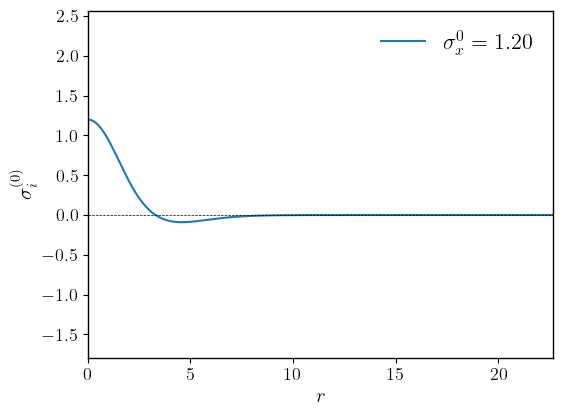

Finding a profile with nodes: [1]
Solution found: U0 = [2.57999335] radius 20.80052017506059


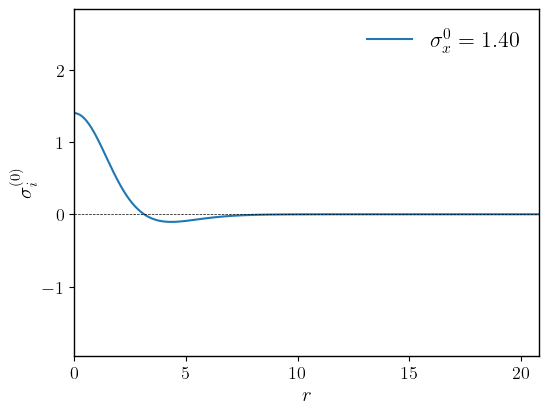

Finding a profile with nodes: [1]
Solution found: U0 = [2.82019984] radius 19.917540001675942


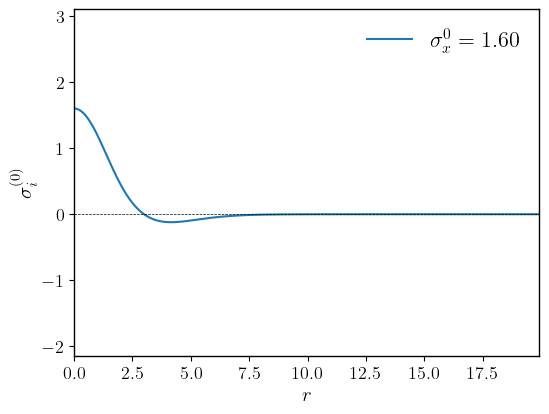

Finding a profile with nodes: [1]
Solution found: U0 = [3.05057401] radius 19.936232206822083


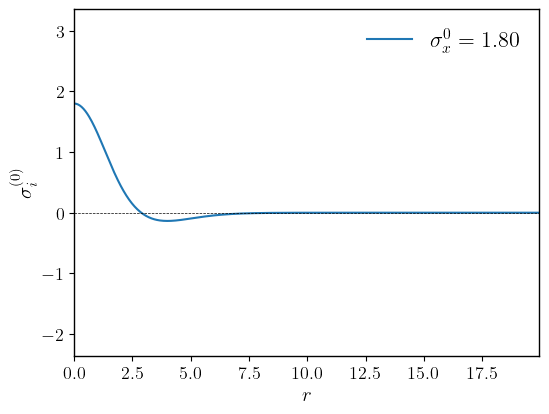

Finding a profile with nodes: [1]
Solution found: U0 = [3.27255203] radius 18.815345374323407


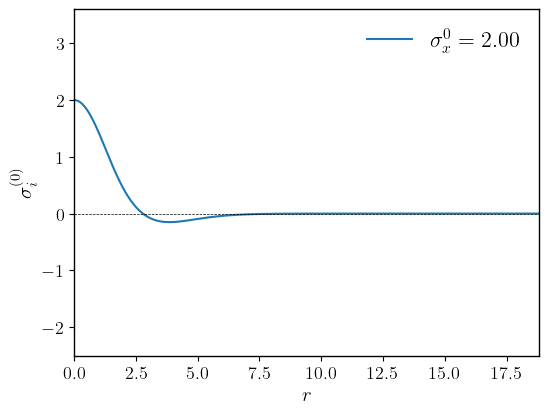

Finding a profile with nodes: [1]
Solution found: U0 = [3.48723876] radius 17.644303450361175


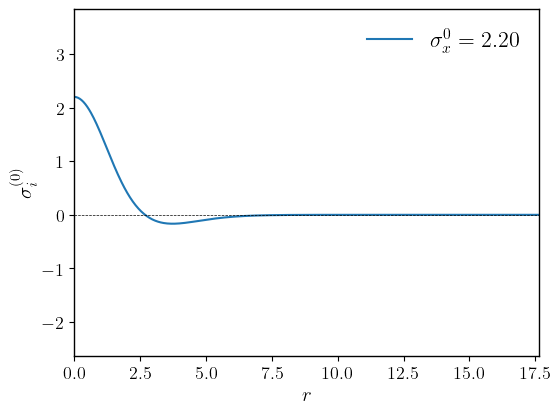

Finding a profile with nodes: [1]
Solution found: U0 = [3.69550724] radius 18.91898535143722


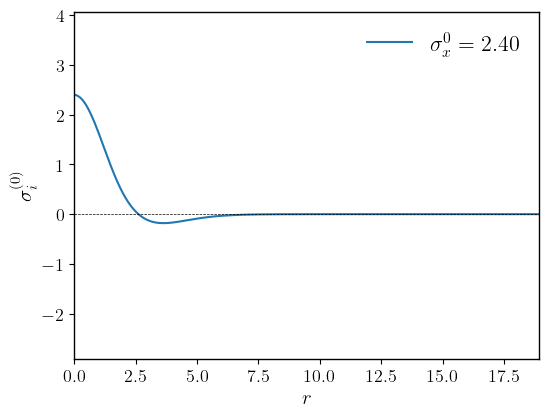

Finding a profile with nodes: [1]
Solution found: U0 = [3.89806247] radius 16.906898041150203


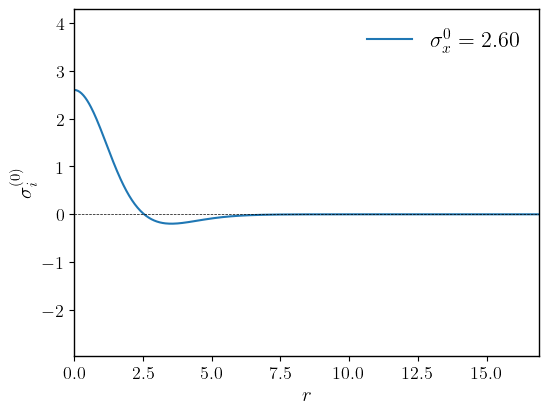

Finding a profile with nodes: [1]
Solution found: U0 = [4.09548416] radius 16.88092282899674


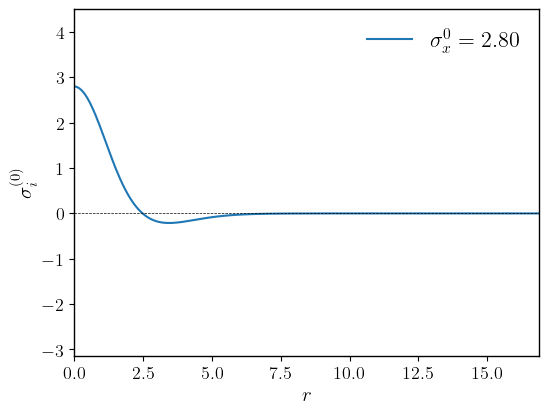

Finding a profile with nodes: [1]
Solution found: U0 = [4.28825628] radius 16.35532310043359


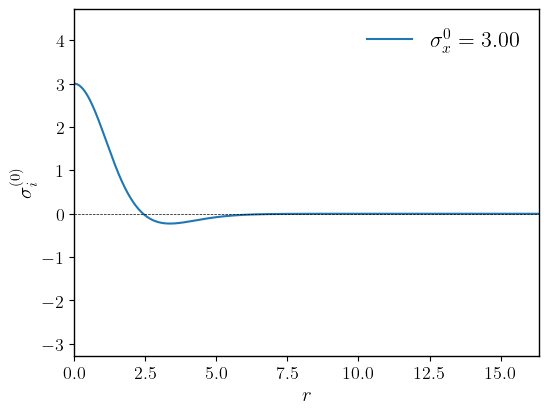

Finding a profile with nodes: [1]
Solution found: U0 = [4.4767882] radius 16.10939063037185


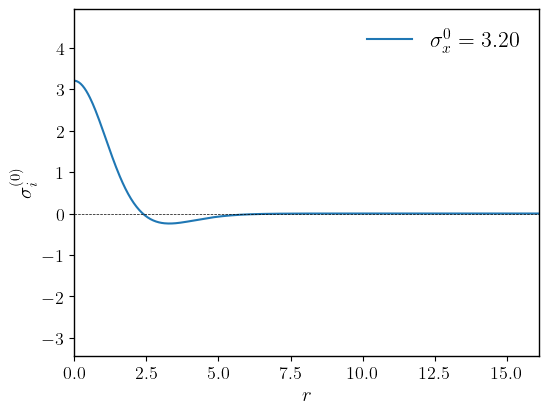

Finding a profile with nodes: [1]
Solution found: U0 = [4.66143007] radius 15.622183768951302


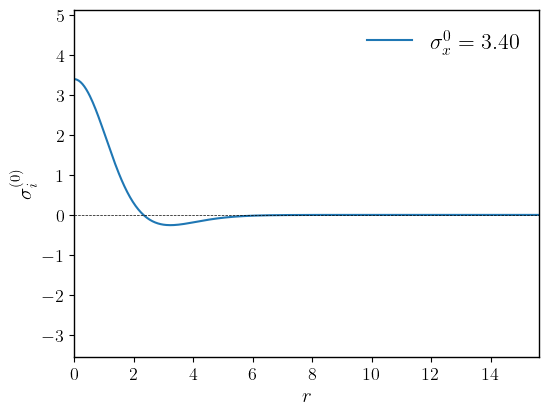

Finding a profile with nodes: [1]
Solution found: U0 = [4.84248439] radius 15.530470014343926


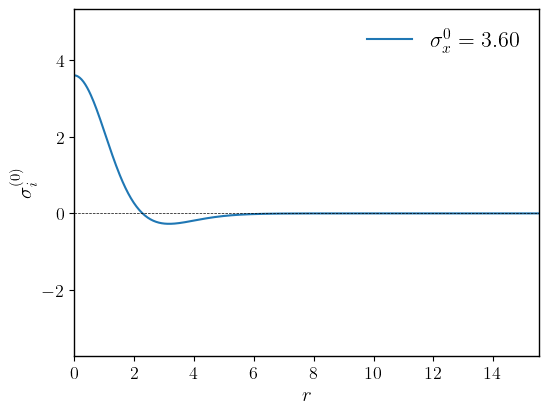

Finding a profile with nodes: [1]
Solution found: U0 = [5.02021473] radius 15.093966616225291


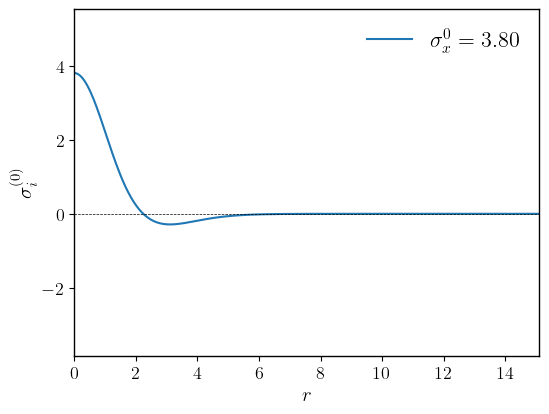

Finding a profile with nodes: [1]
Solution found: U0 = [5.19485253] radius 15.669055763999083


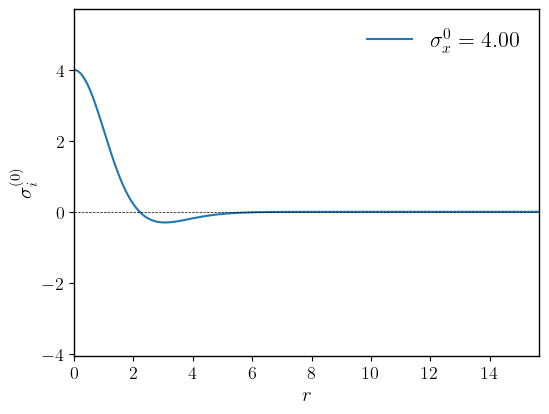

Finding a profile with nodes: [1]
Solution found: U0 = [5.36660243] radius 14.32890524813711


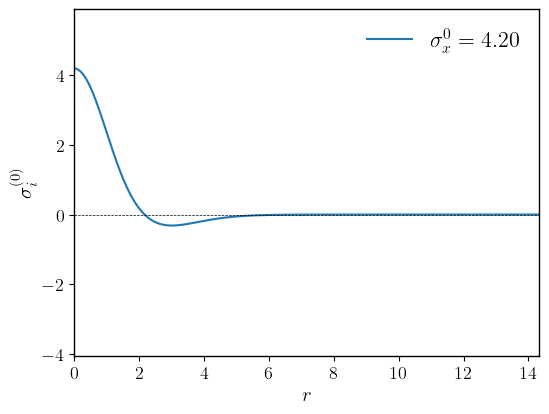

Finding a profile with nodes: [1]
Solution found: U0 = [5.53564647] radius 15.042555370413695


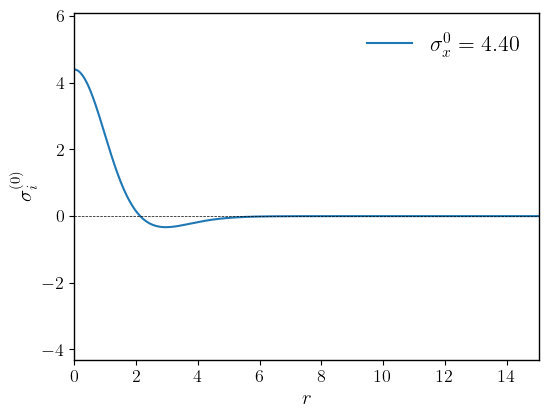

Finding a profile with nodes: [1]
Solution found: U0 = [5.70214754] radius 14.477098375867147


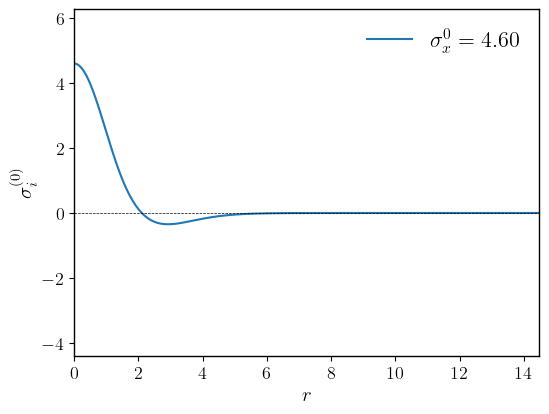

Finding a profile with nodes: [1]
Solution found: U0 = [5.86625207] radius 14.494700179545253


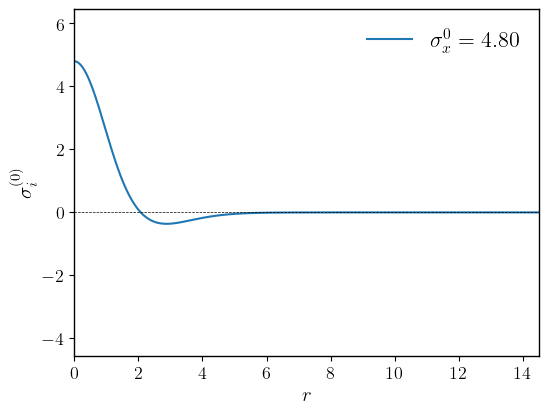

Finding a profile with nodes: [1]
Solution found: U0 = [6.02809237] radius 13.550261525361456


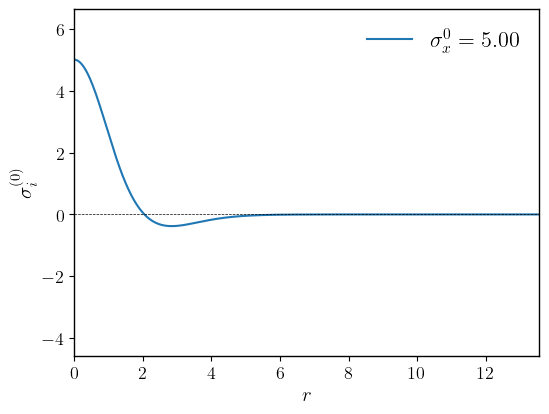

In [6]:
# EXAMPLE: Proca stars radially polarized Proca stars

LambT = 0 # autointeracción: 1 (repulsive), 0 (without selinteraction), -1 (attractive)

nx = 1  # node numbers: nx -> nodes of \sigma_x, ny  -> nodes of \sigma_y, ...
nodos = [nx]  # list of node info

p1x = 0  # The central amplitude of \sigma_x (p0x) and its first derivative value (p1x), the latter is zero
u1x = 0 # The first derivatives of the x.

Ini0 = [None, p1x, u1x]  # boundary conditions list
rmax = 5000  # iteration radius

# Range of values used as seed for the effective potential
Uxint = [0.00012057279119421096, 18]

met = 'DOP853'
gamma = 1  # gamma = 1 for radially polarized Proca stars

# IMPORTANT: the number of fields must be equal to the number of effective potential components
datos = []
for p0x in s0val:
    Ini0[0] = p0x
    Uintrs = [Uxint]
               
    numFields = len(Uintrs)
    Rtol = 1e-13 
    Atol = 1e-15

    u0Val, rTmax, events = bg.MultFreq_solveG2(Ini0, numFields=numFields, Uintrs=Uintrs, rmax=rmax, LambT=LambT, gamma=gamma, met=met,
                                                nodos=nodos, lim=1e-16, info=False, klim=5000, outval=0, delta=0., Rtol=Rtol, Atol=Atol)

    # plot the result
    U0 = np.zeros(4*numFields)
    U0[:2*numFields] = Ini0[:2*numFields]
    U0[2*numFields+1::2] = Ini0[2*numFields:]
    U0[2*numFields::2] = u0Val
    arg = [numFields, LambT, gamma]

    cplot.plotPerf(U0, rTmax, arg=arg)

    # f0, rmax, gamma, LambT, nodes, posNodes, met, Rtol, Atol, u0
    datos.append([U0[0], rTmax, gamma, LambT, nodos[0], None, met, Rtol, Atol, U0[2]])

Mass values: [1.538477578072629]
Eigenvalues of energy: [-0.02082480331094569]


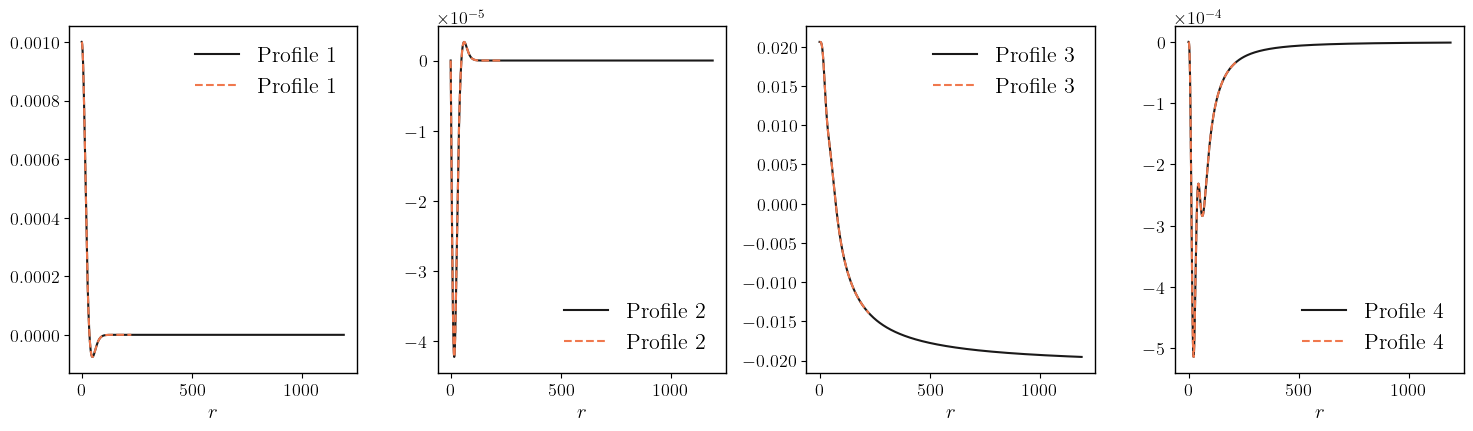

Mass values: [3.3145494546170813]
Eigenvalues of energy: [-0.09666017517516777]


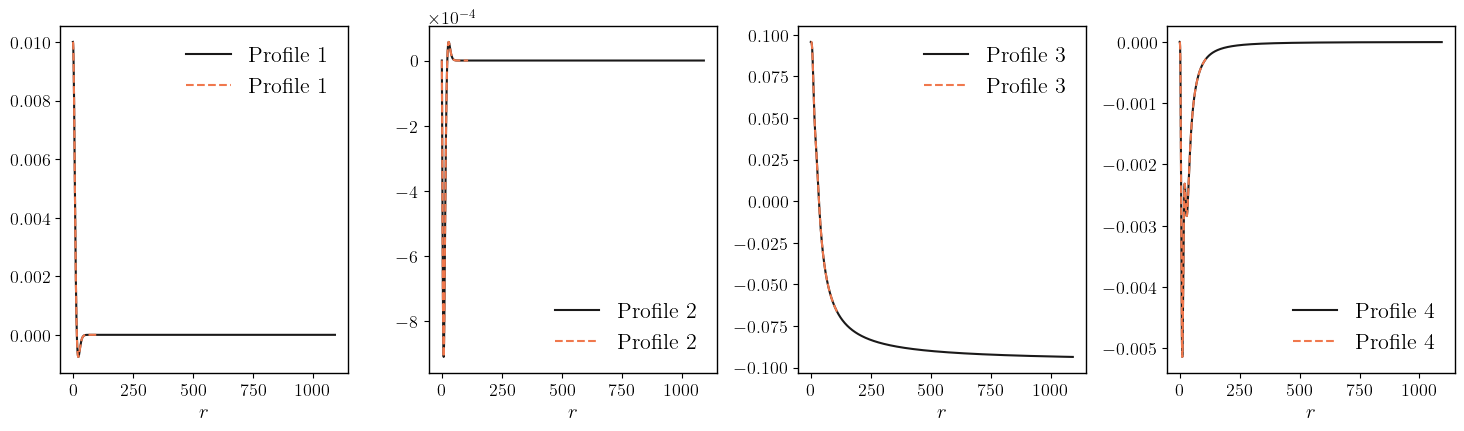

Mass values: [5.6677998425432605]
Eigenvalues of energy: [-0.2826360664353076]


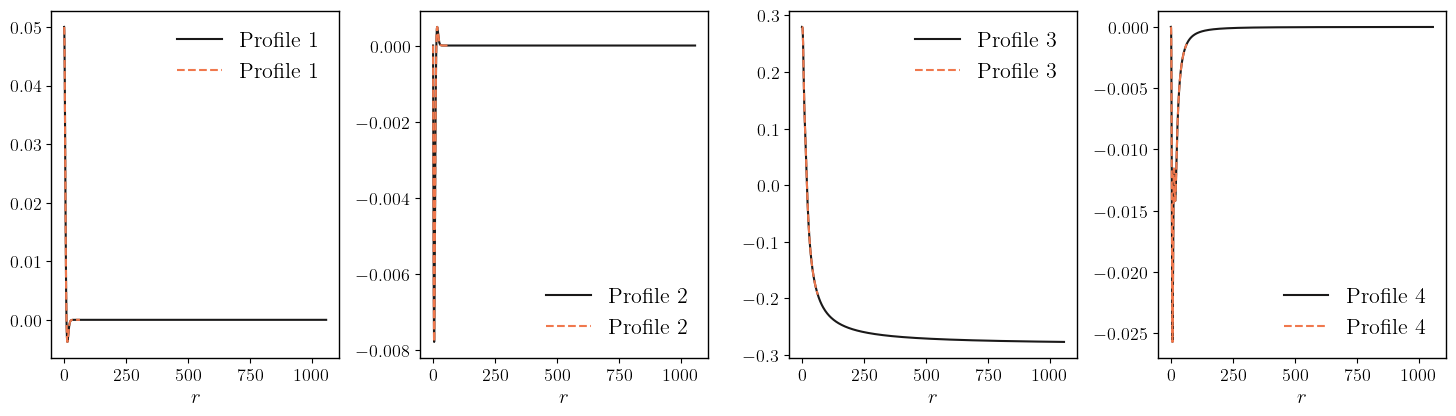

Mass values: [7.140980328416019]
Eigenvalues of energy: [-0.4486567891105657]


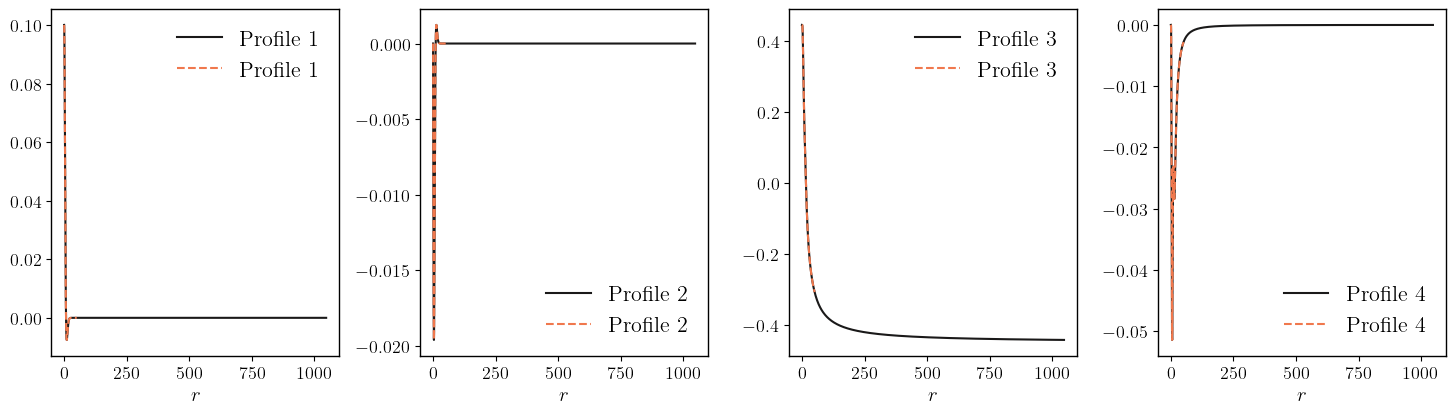

Mass values: [12.210904597079496]
Eigenvalues of energy: [-1.3118804098526966]


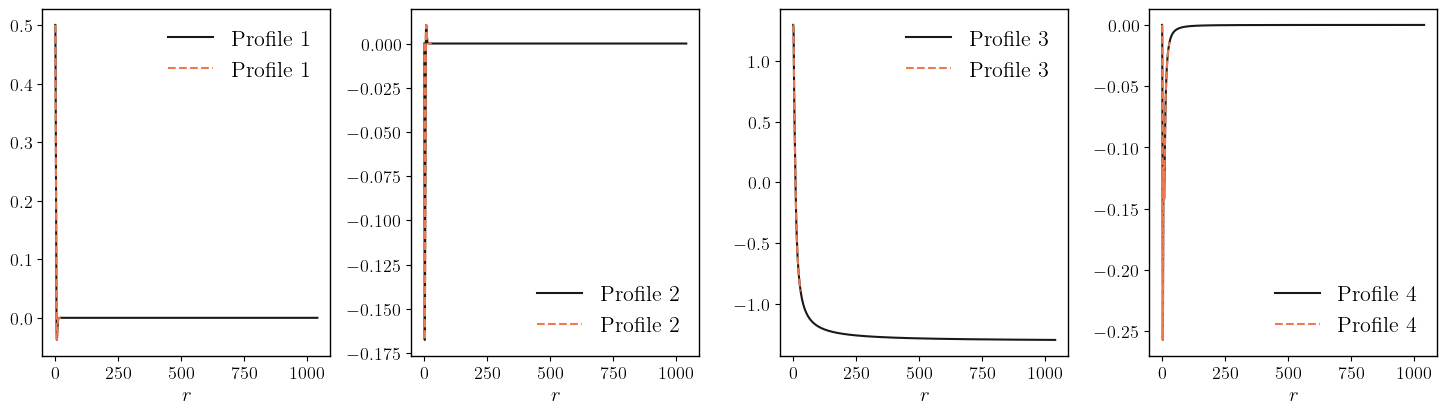

Mass values: [14.281960654086685]
Eigenvalues of energy: [-1.794627158628551]


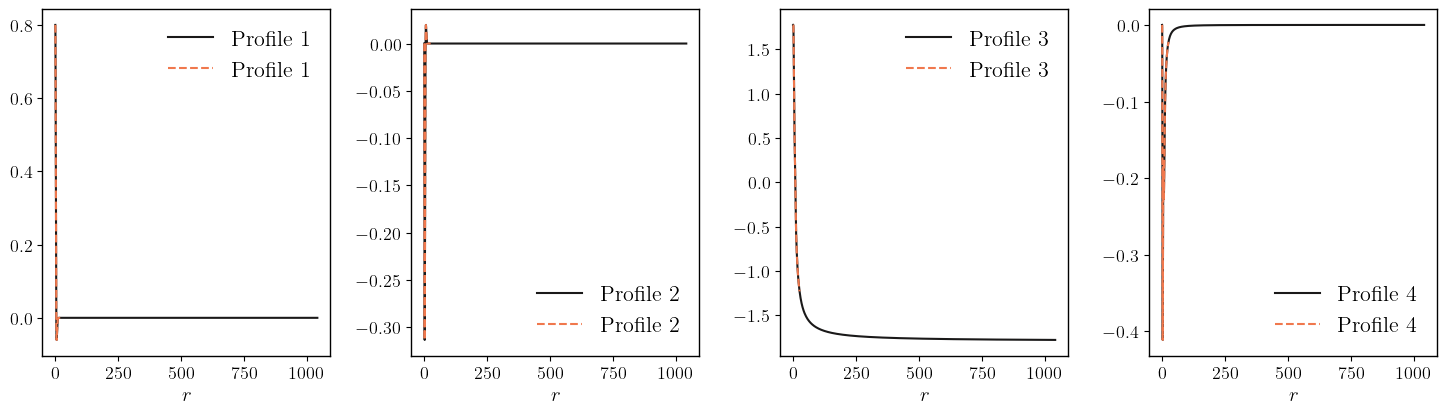

Mass values: [15.384775735293648]
Eigenvalues of energy: [-2.0824803473903177]


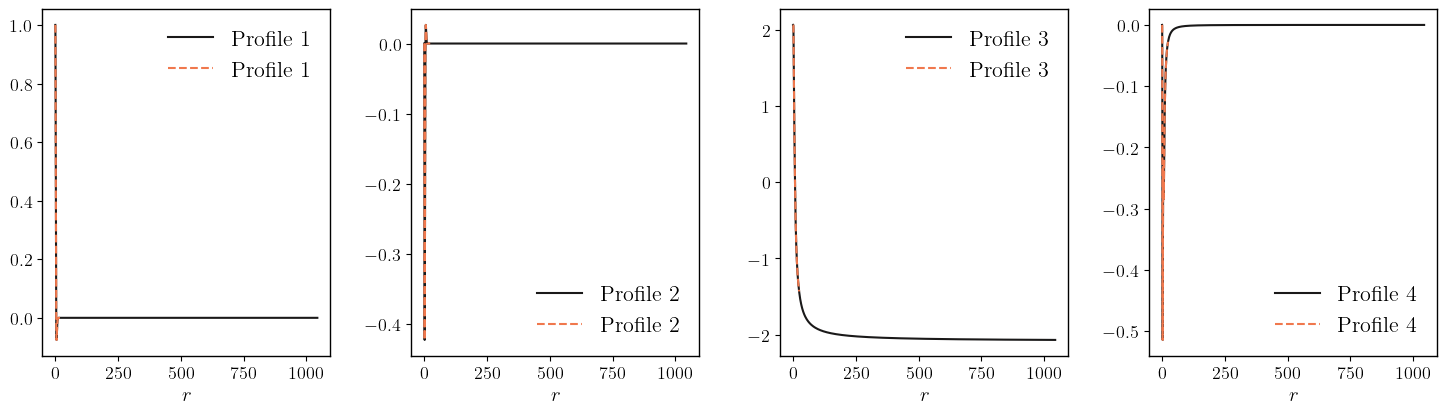

Mass values: [16.34876376554792]
Eigenvalues of energy: [-2.3516268565056526]


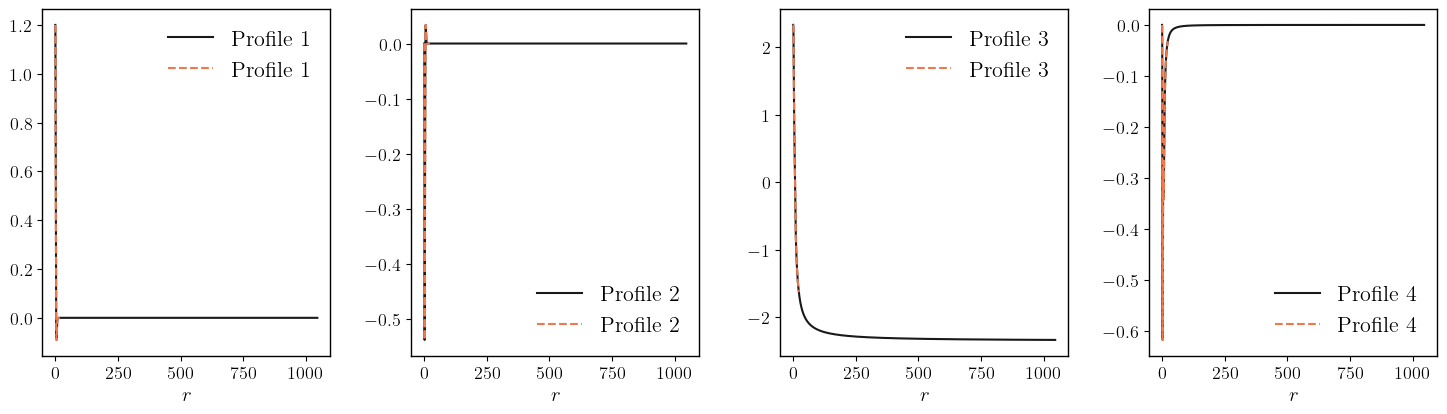

Mass values: [17.210778503581118]
Eigenvalues of energy: [-2.60615115147323]


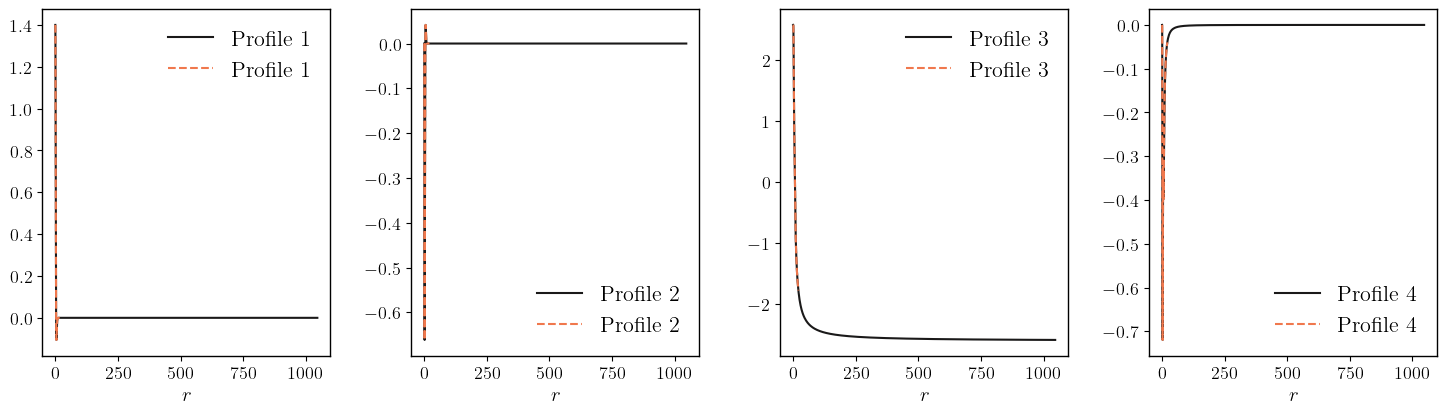

Mass values: [17.994142870998026]
Eigenvalues of energy: [-2.848793031860133]


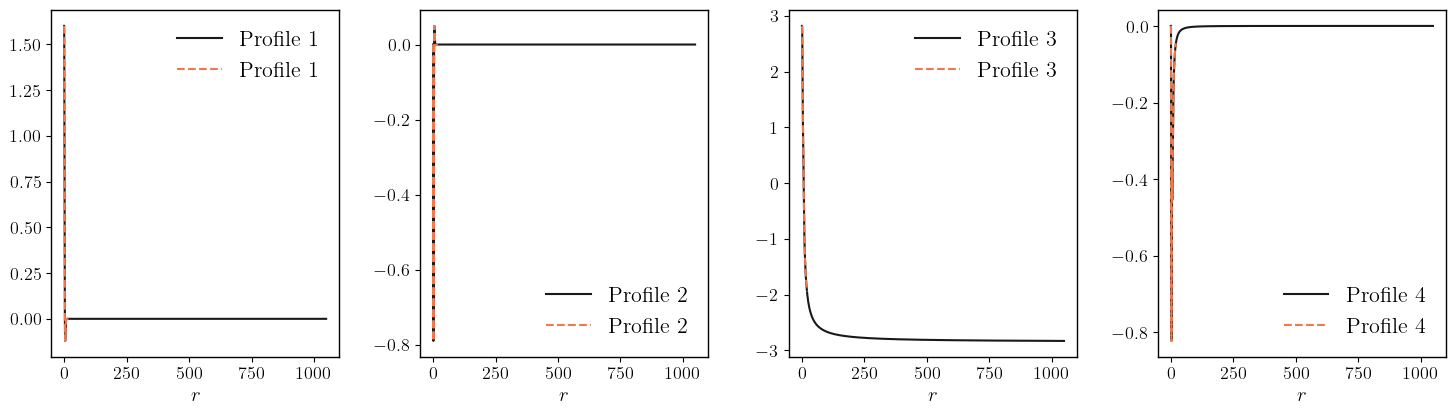

Mass values: [18.71466273118138]
Eigenvalues of energy: [-3.0815029331283688]


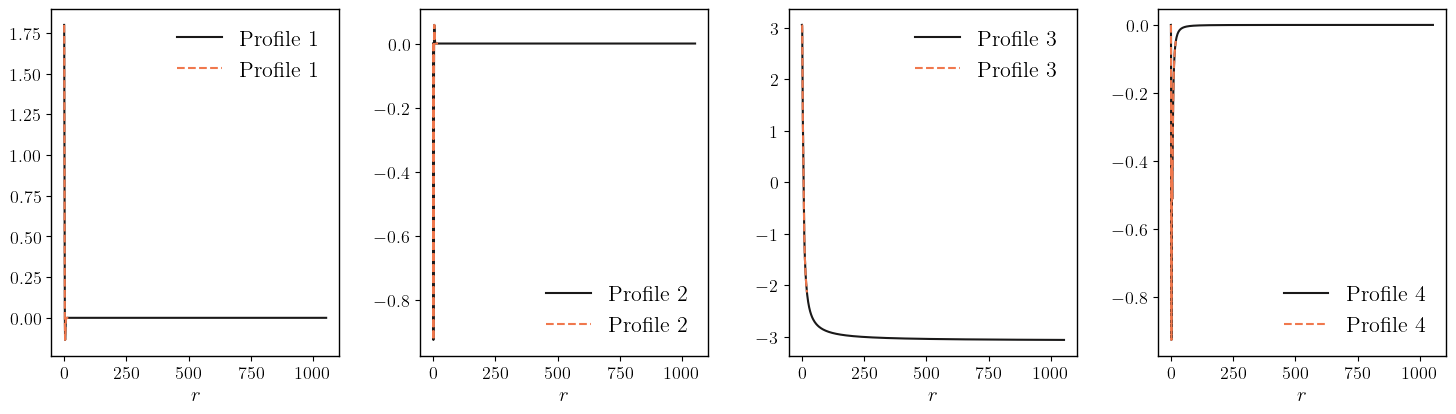

Mass values: [19.383602796046674]
Eigenvalues of energy: [-3.305731495454701]


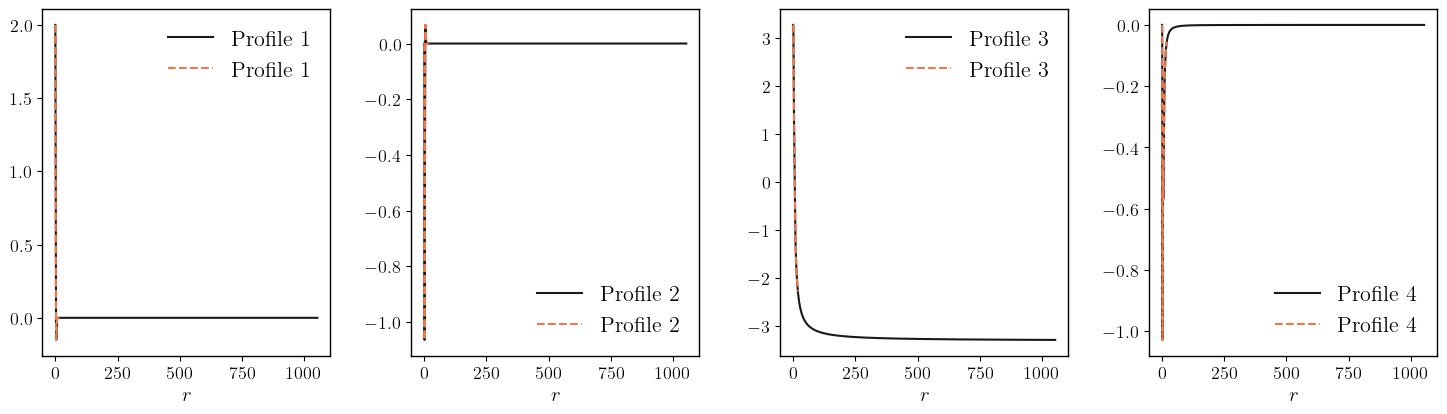

Mass values: [20.009307763242276]
Eigenvalues of energy: [-3.5225948524624826]


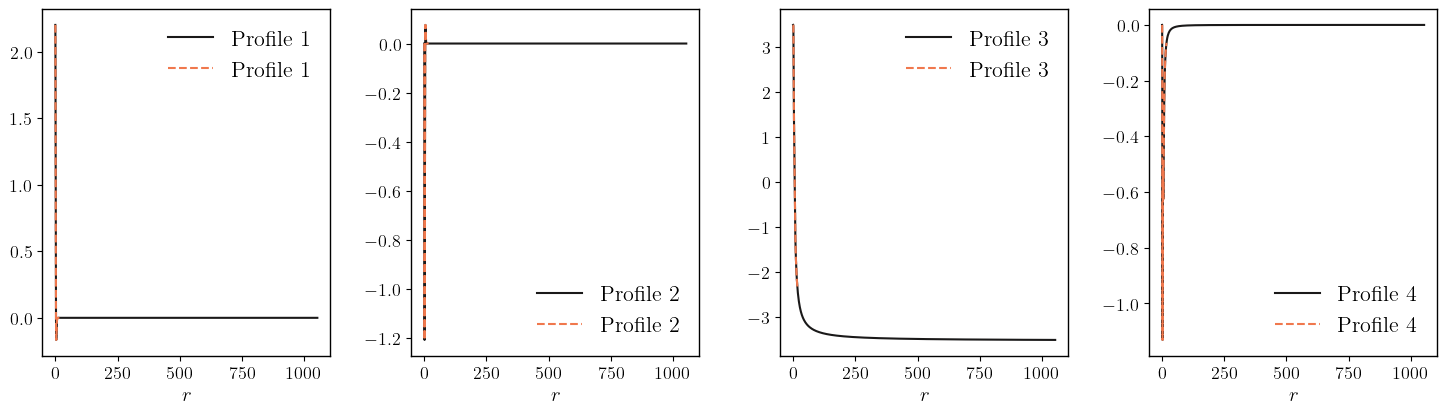

Mass values: [20.598151563043512]
Eigenvalues of energy: [-3.732975057714123]


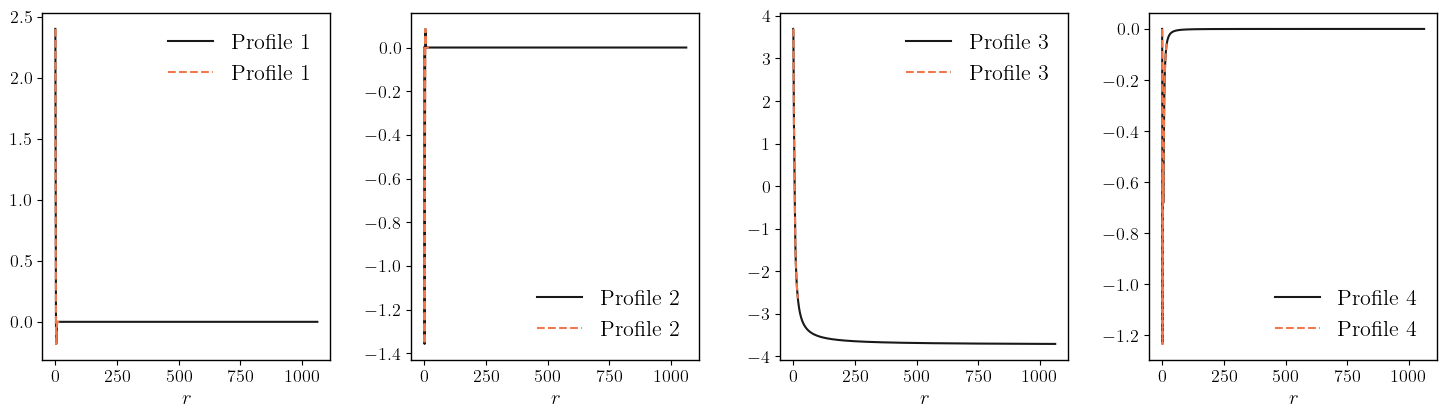

Mass values: [21.155126156388818]
Eigenvalues of energy: [-3.9375837894574675]


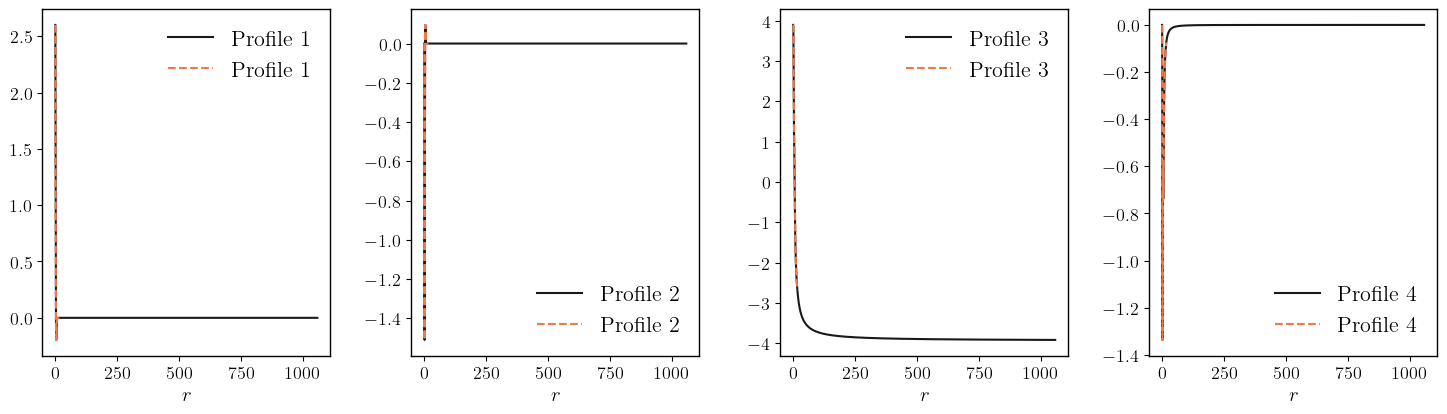

Mass values: [21.684222103656346]
Eigenvalues of energy: [-4.1370071024117845]


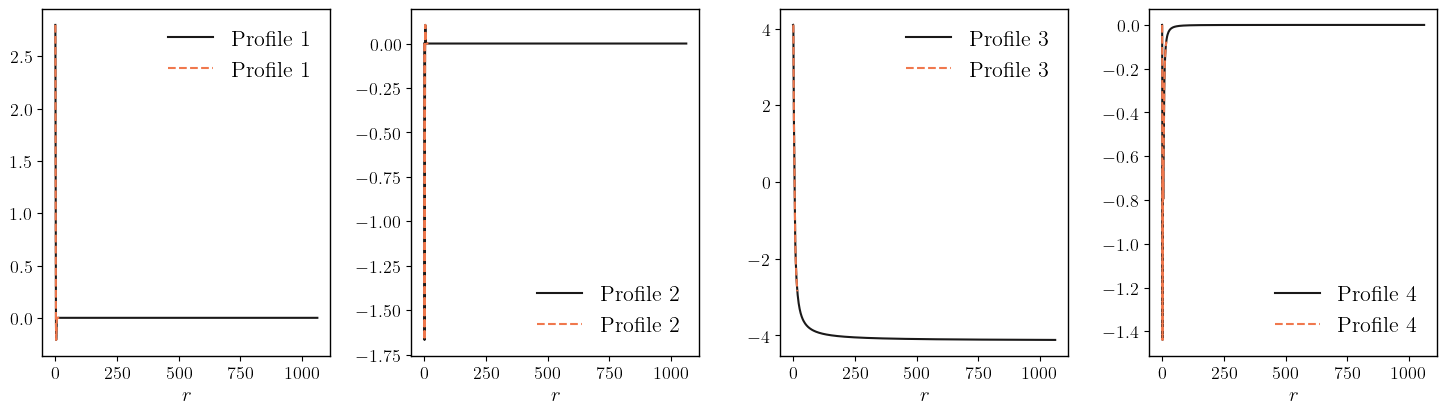

Mass values: [22.18868619606434]
Eigenvalues of energy: [-4.331733678179438]


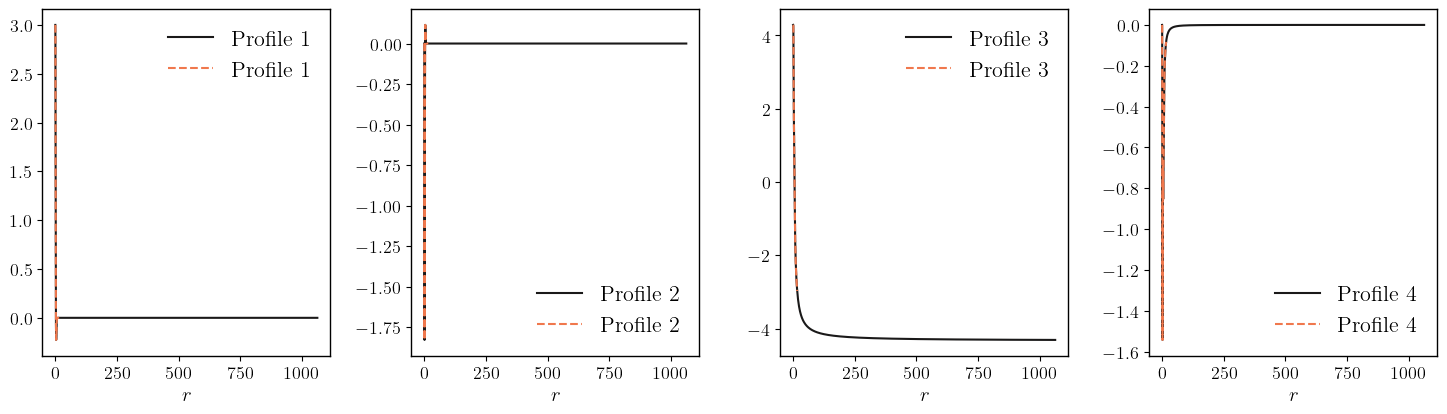

Mass values: [22.671199361603346]
Eigenvalues of energy: [-4.522177076590554]


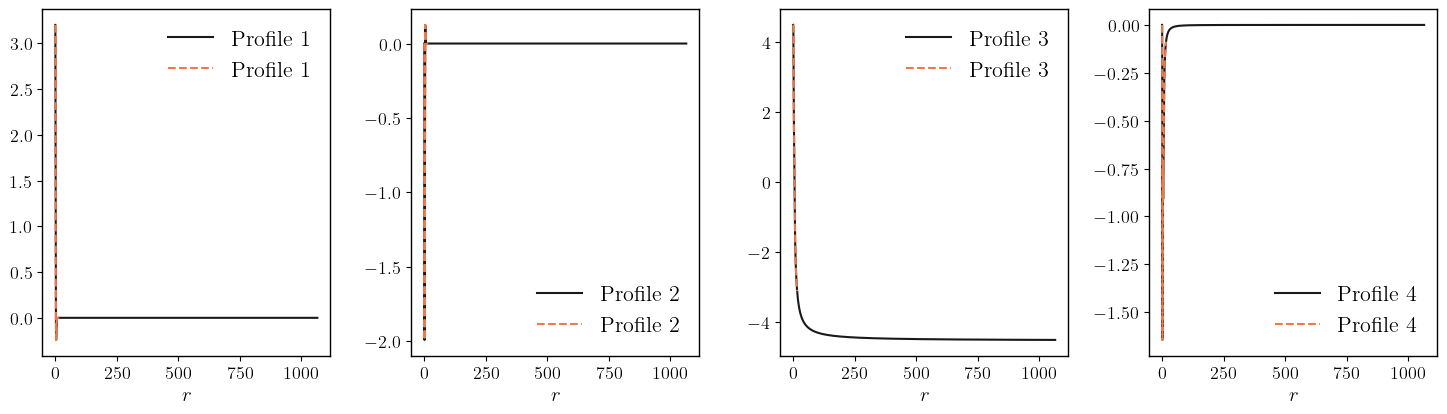

Mass values: [23.134004143233266]
Eigenvalues of energy: [-4.708690970022705]


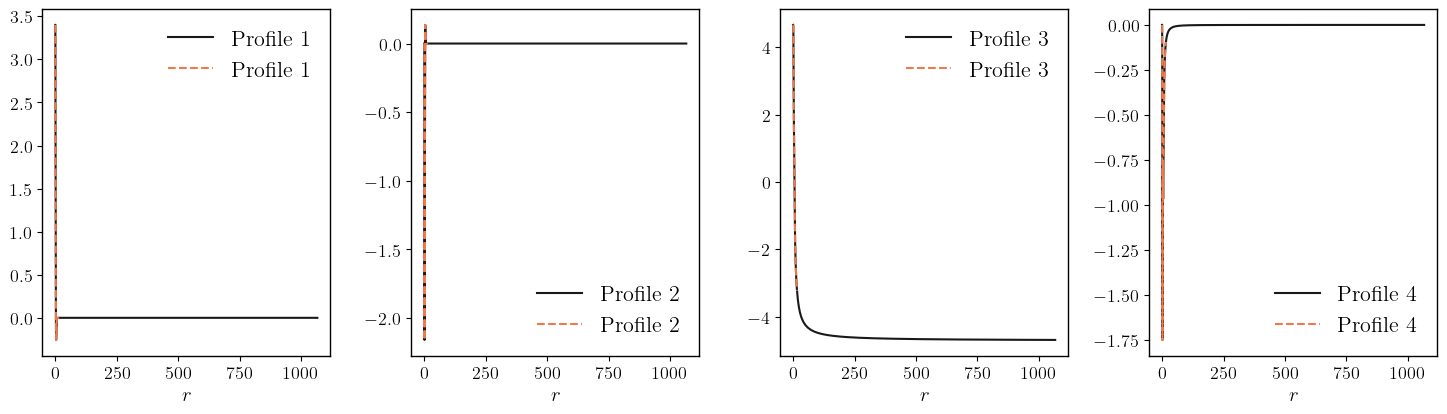

Mass values: [23.578997519149585]
Eigenvalues of energy: [-4.891580963190902]


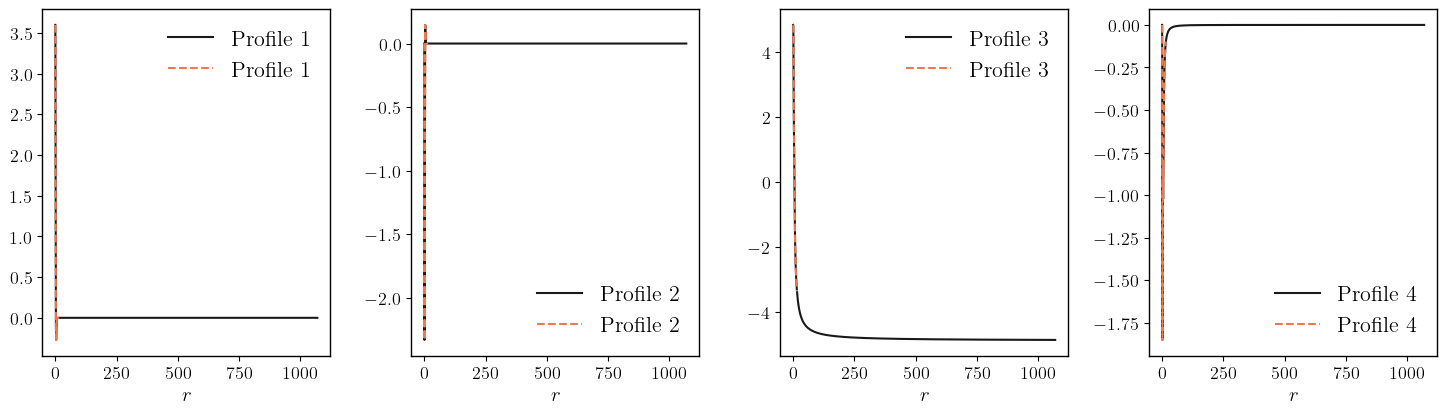

Mass values: [24.007800240660867]
Eigenvalues of energy: [-5.0711132416114975]


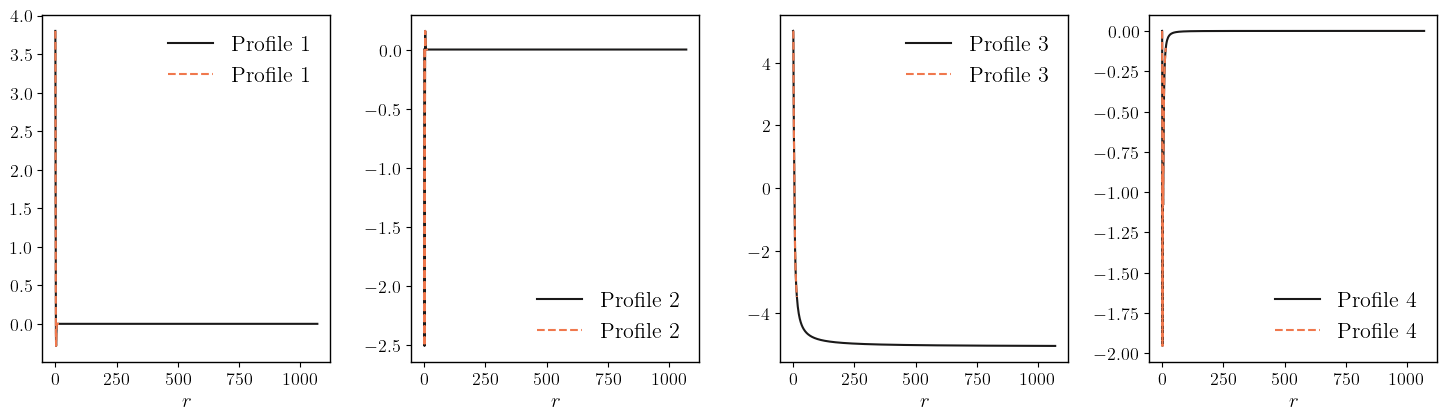

Mass values: [24.42180920554641]
Eigenvalues of energy: [-5.2475217684020805]


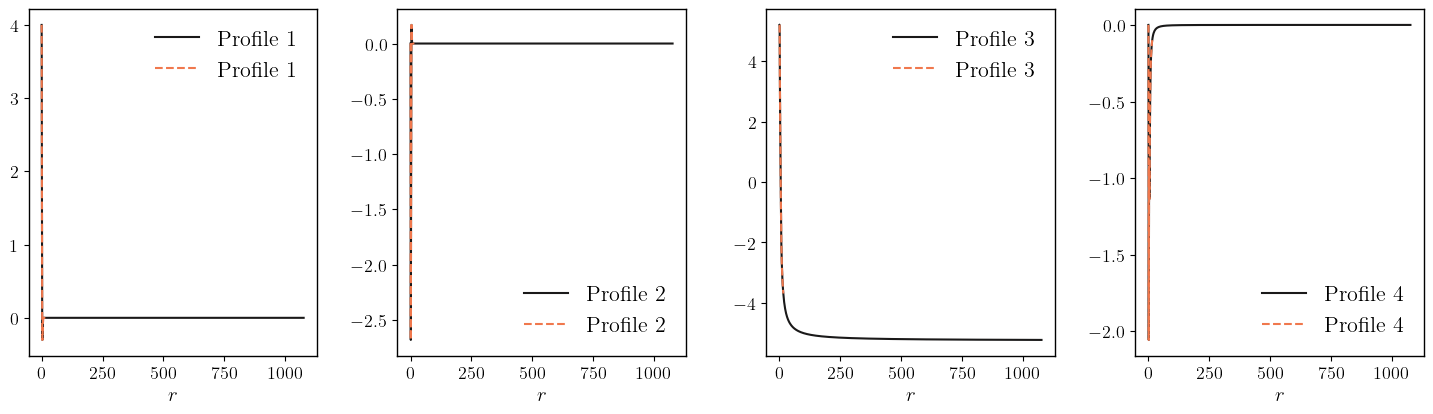

Mass values: [24.82223791021898]
Eigenvalues of energy: [-5.421012844523382]


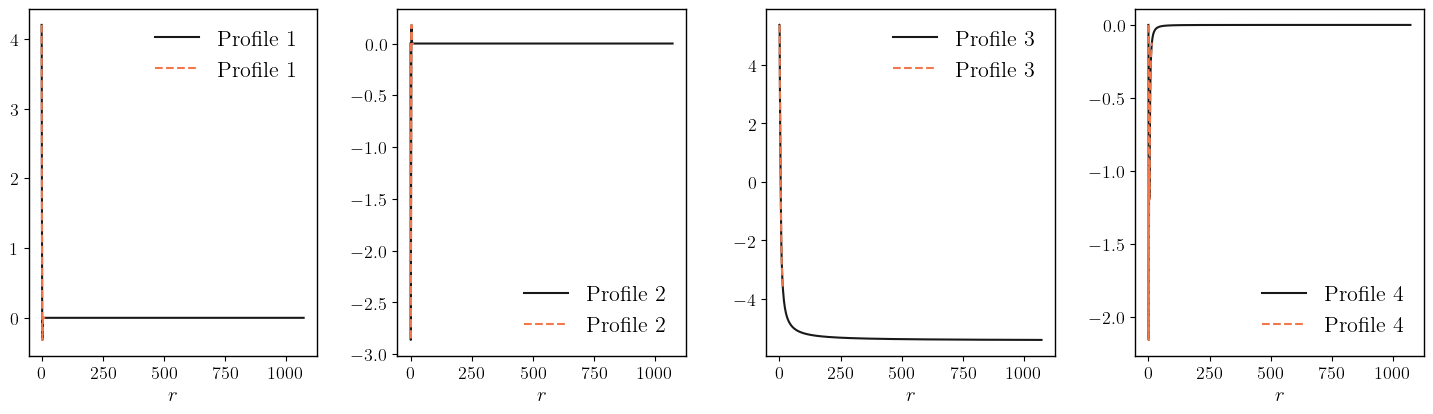

Mass values: [25.21014801267686]
Eigenvalues of energy: [-5.5917709034332255]


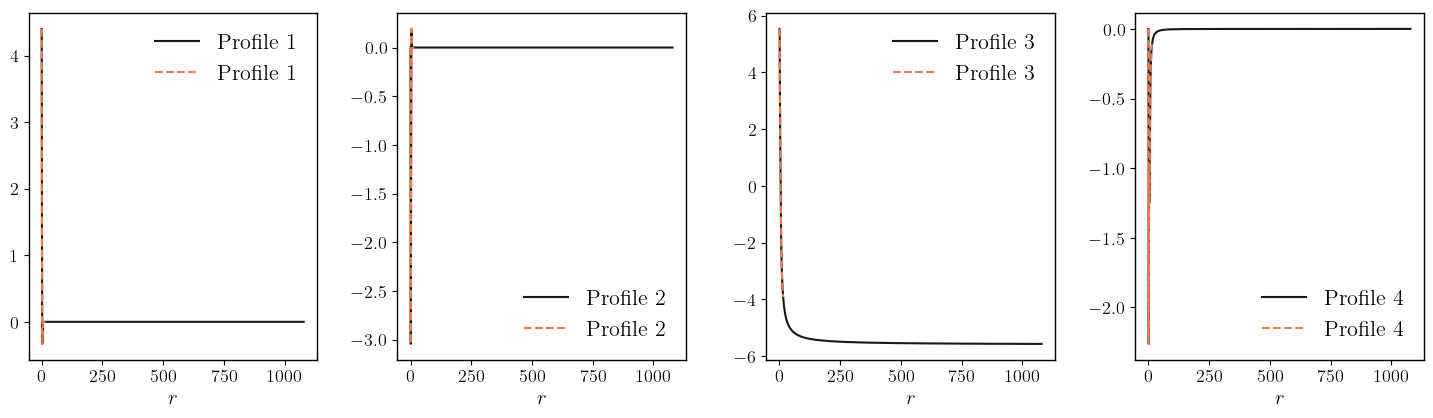

Mass values: [25.586474347149597]
Eigenvalues of energy: [-5.759960013970884]


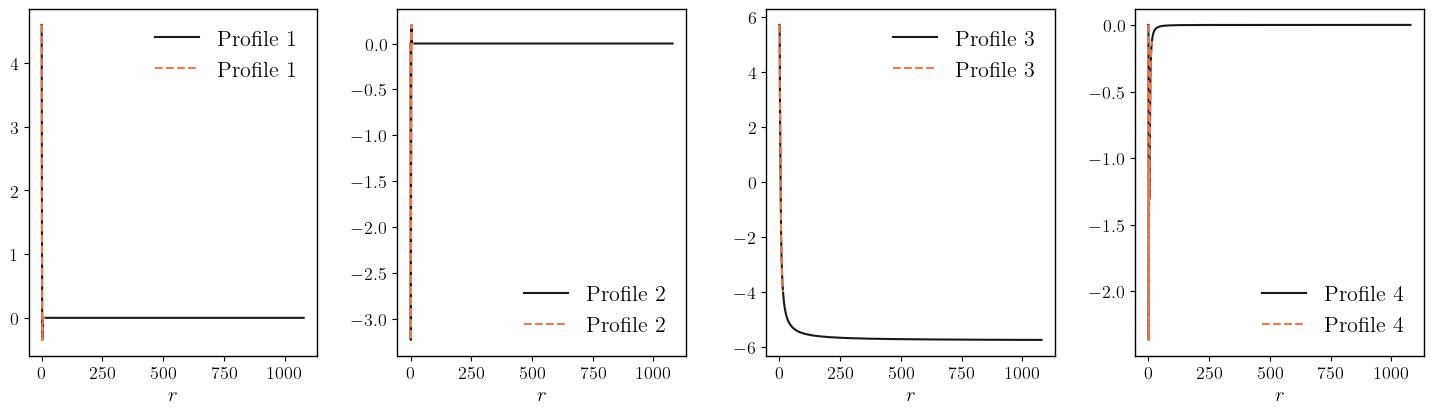

Mass values: [25.952044805005748]
Eigenvalues of energy: [-5.925728397812405]


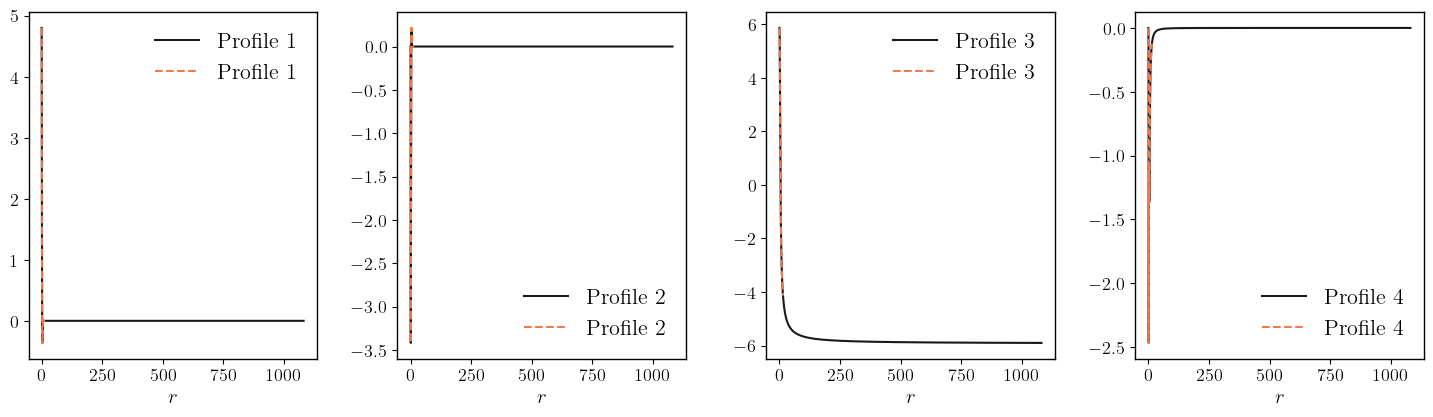

Mass values: [26.307596476834124]
Eigenvalues of energy: [-6.089209445987633]


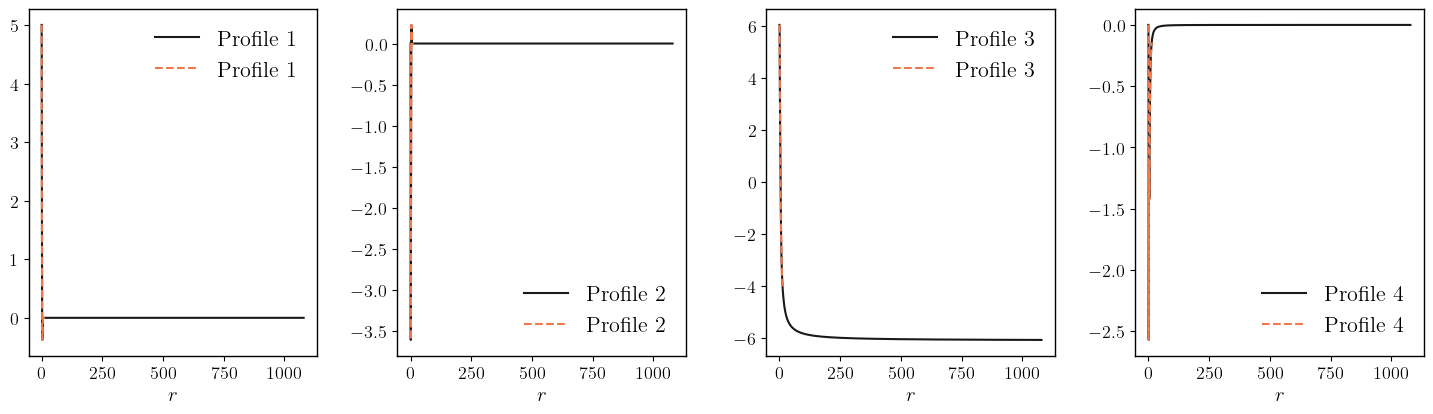

In [7]:
# Extendiendo los perfiles
Ext = 1000 #7000
Np = 1000 #int(2e06)

confidataEx = []
for confi in datos: # confidata datos
    dataEx = bg.mainExt(confi, mult=False, rmin=0, Nptos=Np, met='DOP853', metExp=1, info=True,
                    Rtol=1e-13, Atol=1e-15, deltaExt=Ext, yscale='linear', xscale='linear')  # out [[Ei, rDnew, sDnew, dsDnew, uDnew, duDnew], ..]
    confidataEx.append(dataEx[0])


In [ ]:
# Test scaling
# [[Ei, rDnew, sDnew, dsDnew, uDnew, duDnew], ..]
Ei, rDnew, sDnew, dsDnew, uDnew, duDnew = confidataEx[0]
Ei1, rDnew1, sDnew1, dsDnew1, uDnew1, duDnew1 = confidataEx[1]

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 4),
                       sharex=False, sharey=False,
                       gridspec_kw=dict(hspace=0.0, wspace=.28))

ax[0].plot(rDnew, np.abs(sDnew), label=r'$\sigma_0=%2.1f$'%np.abs(sDnew)[0])
ax[0].plot(rDnew1, np.abs(sDnew1), label=r'$\sigma_0=%2.1f$'%np.abs(sDnew1)[0])
ax[0].legend(frameon=False)
ax[0].set_xlim(0, 50)
ax[0].set_yscale('log')
ax[0].set_ylim(1e-12, 10)

###########
ax[1].plot(rDnew1, rDnew1*sDnew1, label=r'$\sigma_0=%2.1f$'%np.abs(sDnew1)[0])

valmax = np.max(rDnew*sDnew)
valmax1 = np.max(rDnew1*sDnew1)
lambdaSt = valmax1/valmax

ax[1].plot(rDnew/np.sqrt(lambdaSt), (rDnew*sDnew)*lambdaSt, lw=1, label=r'$\sigma_0=%2.1f \times \lambda_*$'%np.abs(sDnew)[0])


ax[1].vlines(x=datos[0][3], ymin=1e-9, ymax=1, color='r', lw=0.5, ls='--')
ax[1].vlines(x=datos[1][3]*np.sqrt(lambdaSt), ymin=1e-9, ymax=1, color='k', lw=0.5, ls='-')

#ax[0].set_yscale('log')
#ax[1].set_yscale('log')
ax[1].set_ylim(-1., 2.01)
ax[1].legend(frameon=False)
ax[1].set_xlim(0, 35)

In [ ]:
print("lambda_* = ", lambdaSt)

Testeando los autovalores

In [8]:
import Modules.SpectralMeth as sp
from scipy.interpolate import interp1d

In [9]:
s0val

[0.001,
 0.01,
 0.05,
 0.1,
 0.5,
 0.8,
 1,
 1.2,
 1.4,
 1.6,
 1.8,
 2,
 2.2,
 2.4,
 2.6,
 2.8,
 3,
 3.2,
 3.4,
 3.6,
 3.8,
 4,
 4.2,
 4.4,
 4.6,
 4.8,
 5]

===>  0.001


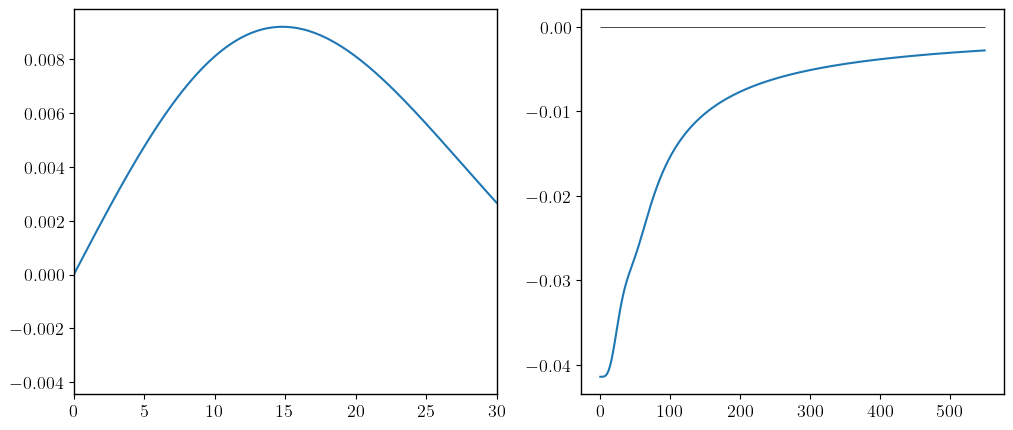

===>  0.01[####################] 100%


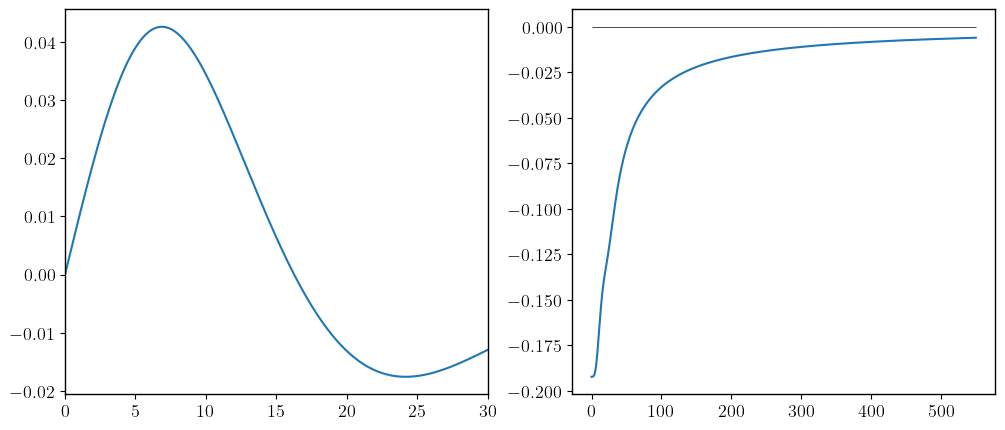

===>  0.05[####################] 100%


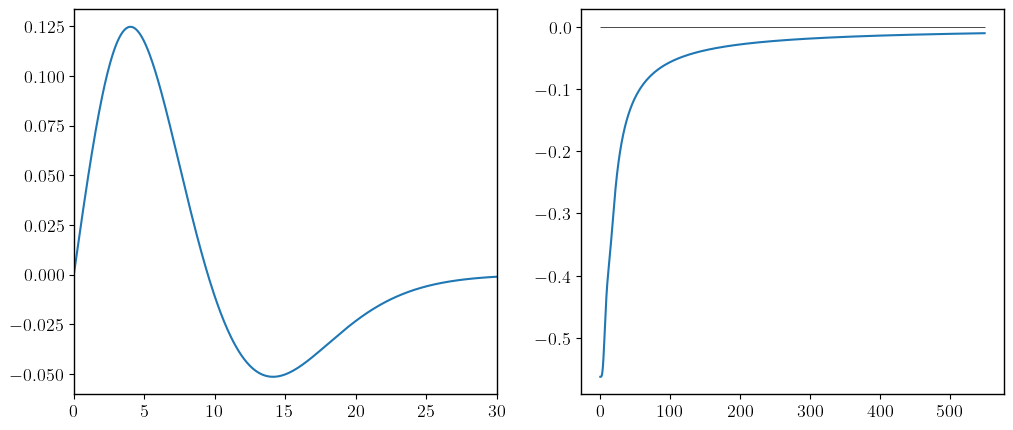

===>  0.1 [####################] 100%


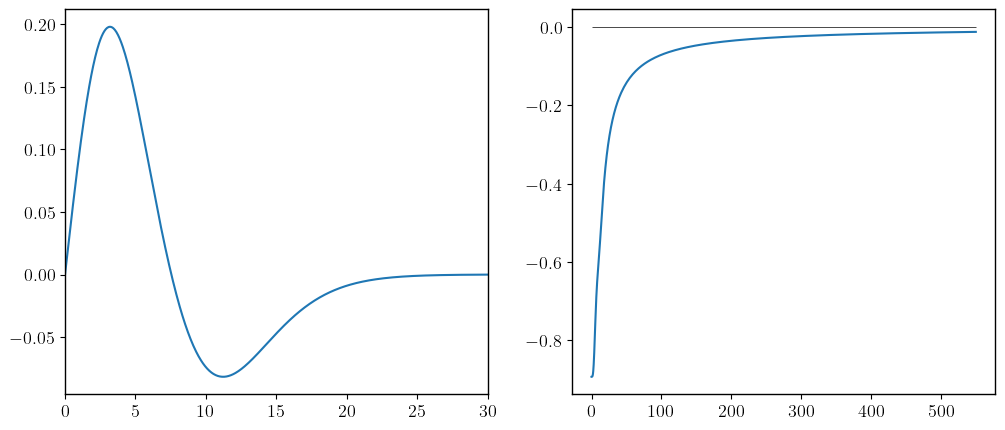

===>  0.5 [####################] 100%


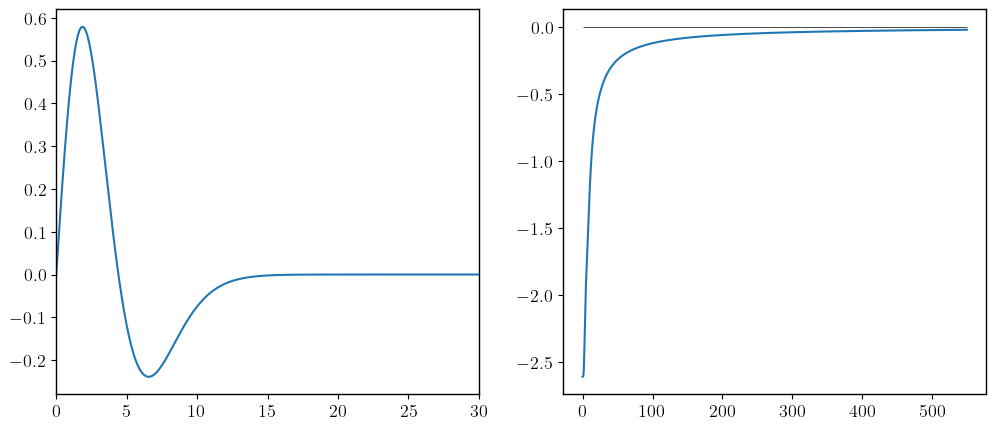

===>  0.8 [####################] 100%


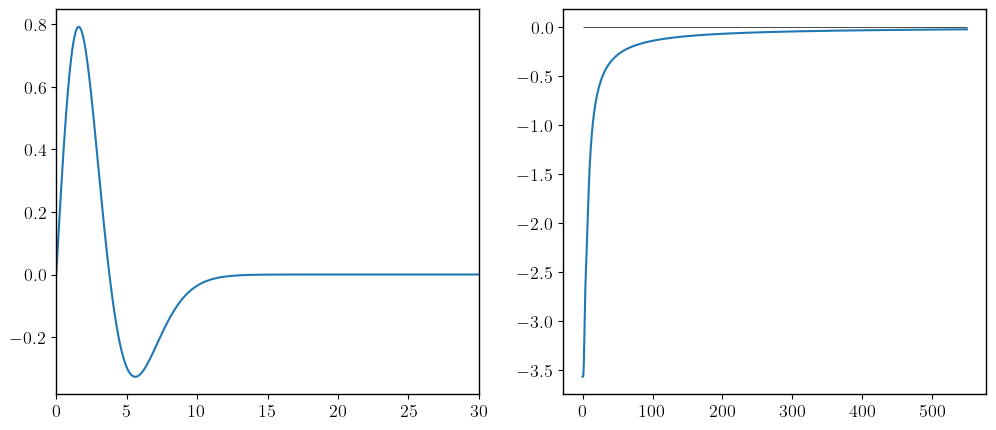

===>  1.0 [####################] 100%


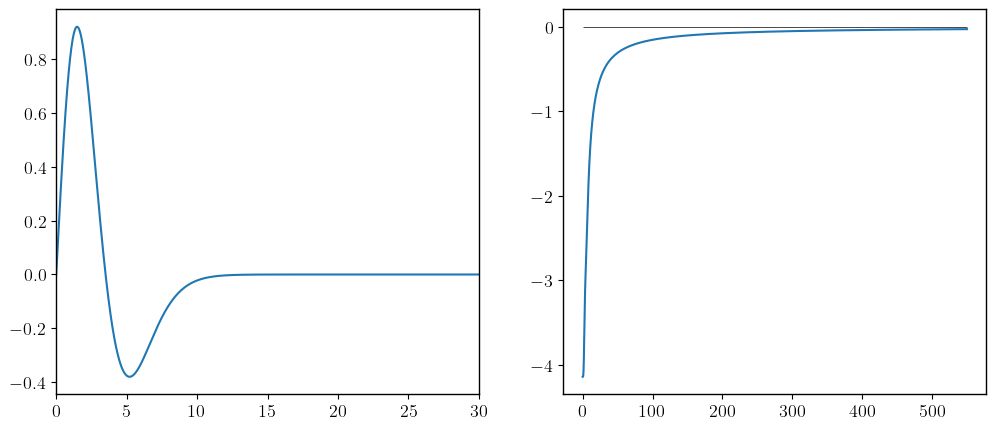

===>  1.2 [####################] 100%


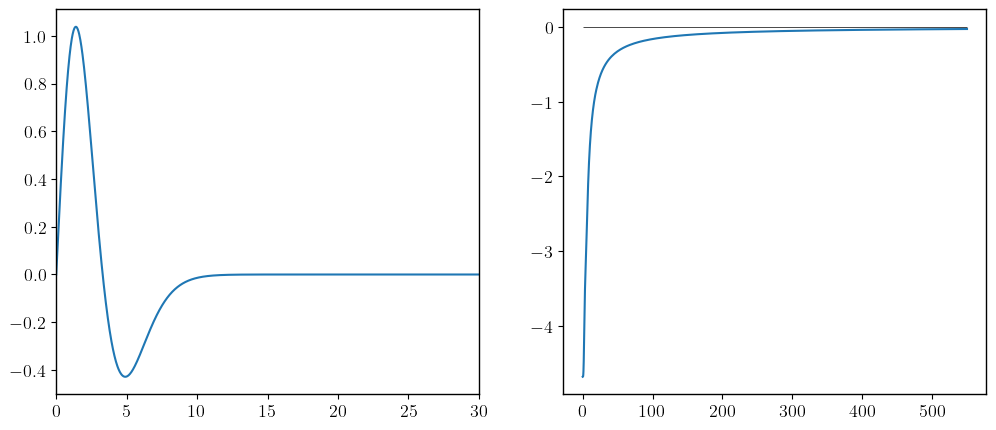

===>  1.4 [####################] 100%


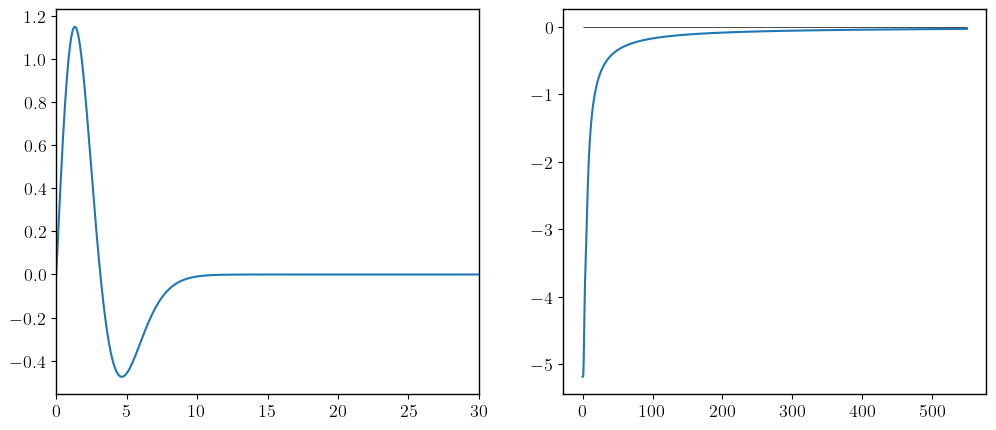

===>  1.6 [####################] 100%


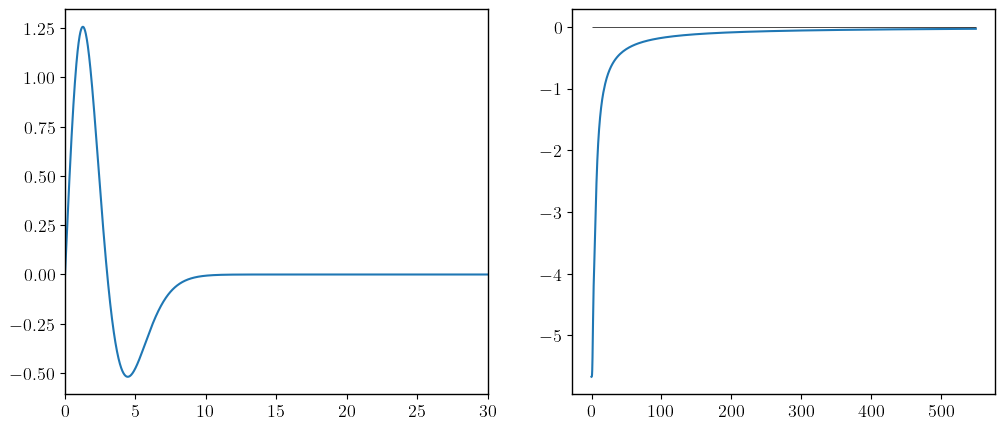

===>  1.8 [####################] 100%


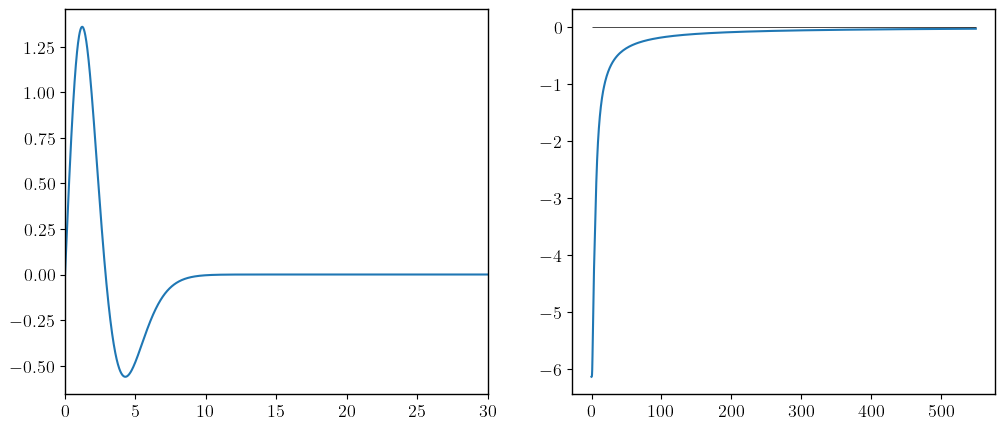

===>  2.0 [####################] 100%


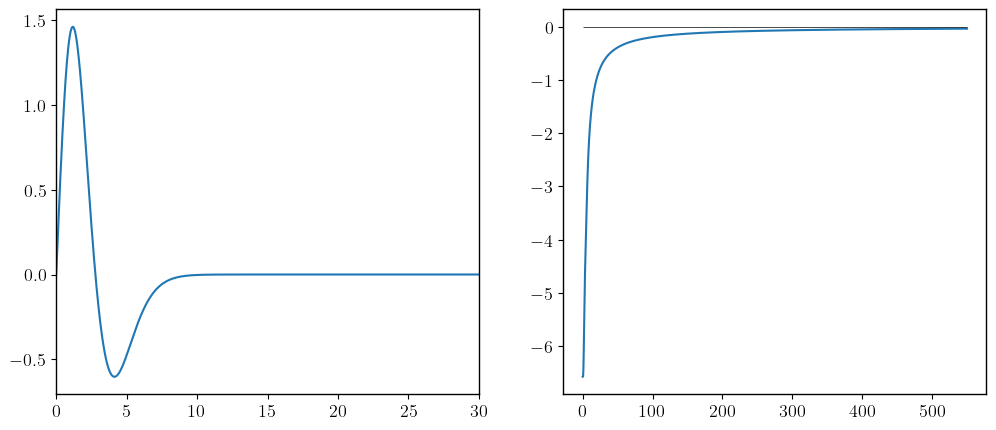

===>  2.2 [####################] 100%


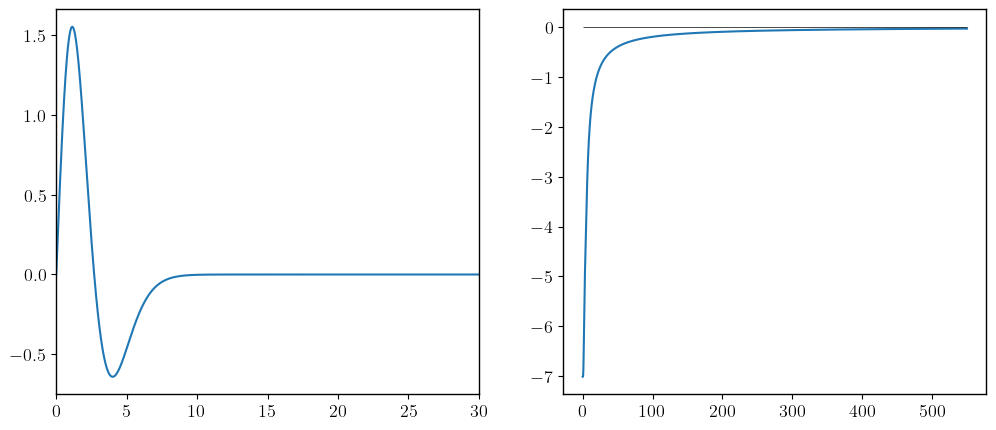

===>  2.4 [####################] 100%


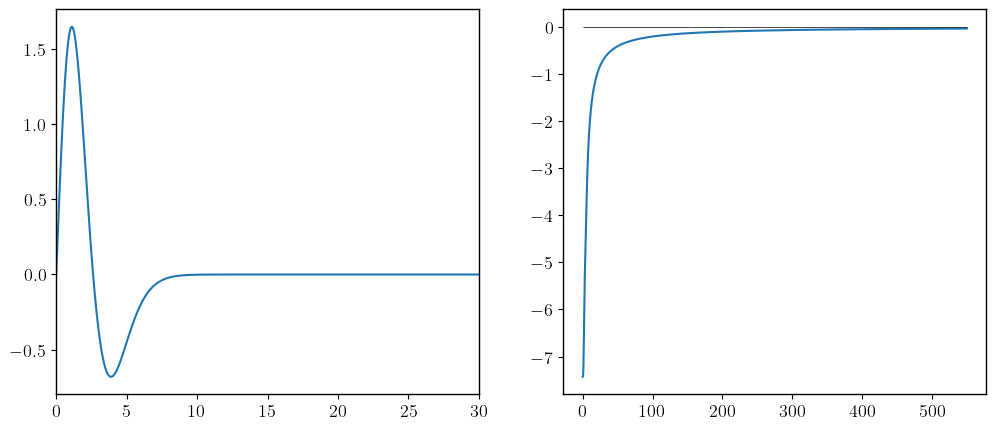

===>  2.6 [####################] 100%


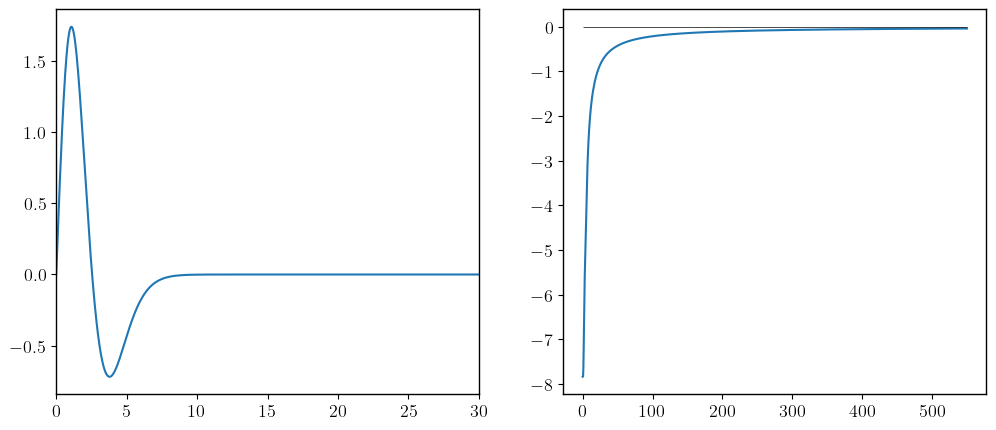

===>  2.8 [####################] 100%


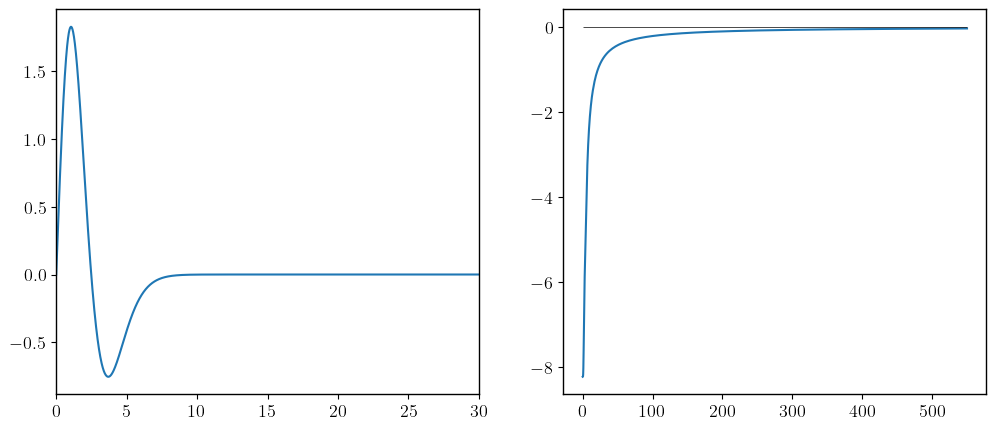

===>  3.0 [####################] 100%


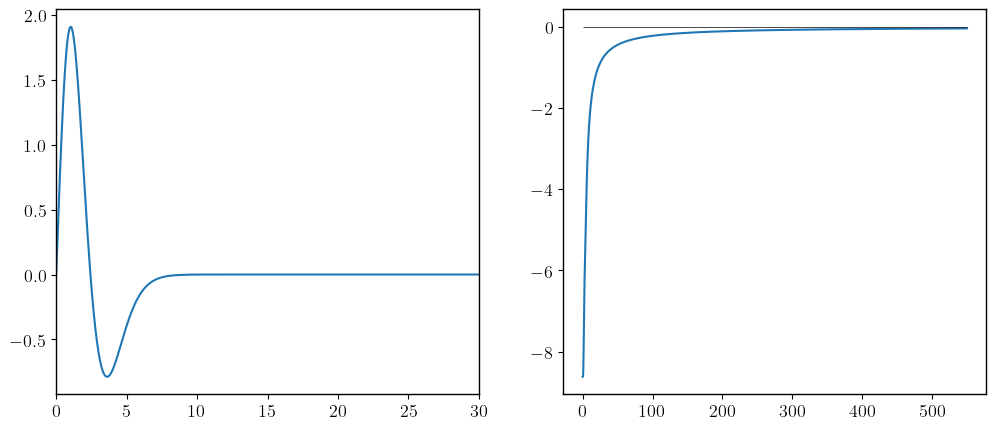

===>  3.2 [####################] 100%


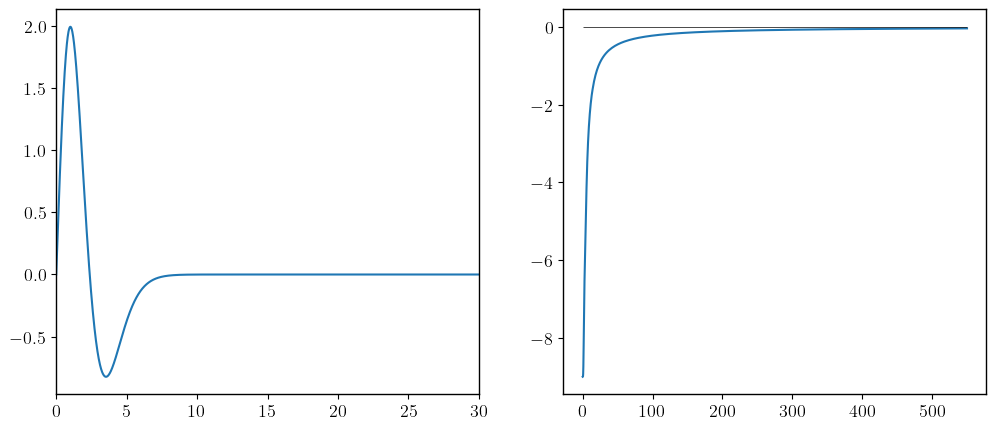

===>  3.4 [####################] 100%


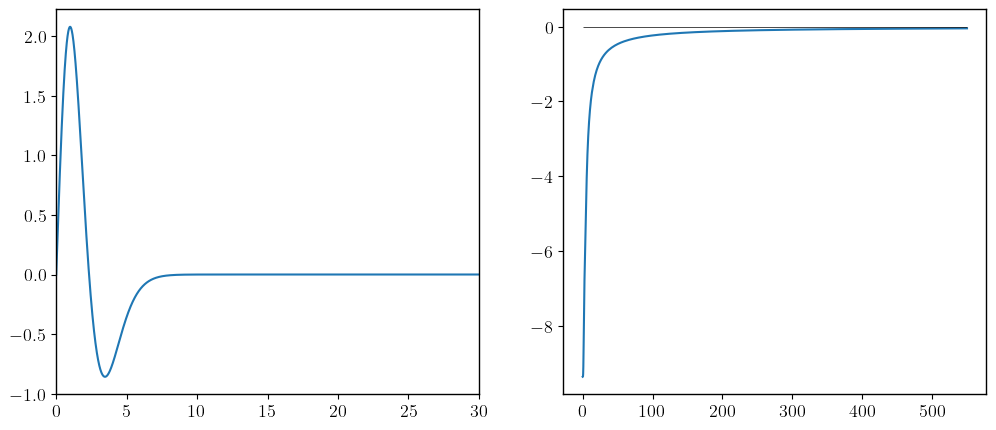

===>  3.6 [####################] 100%


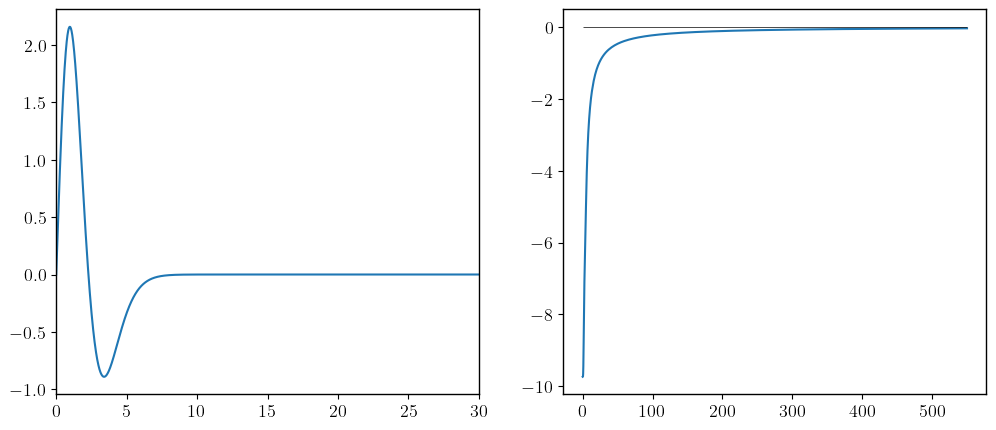

===>  3.8 [####################] 100%


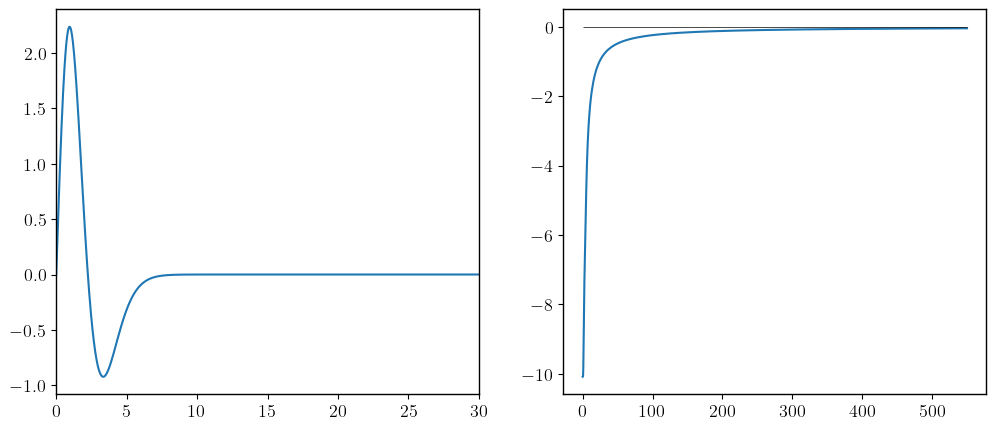

===>  4.0 [####################] 100%


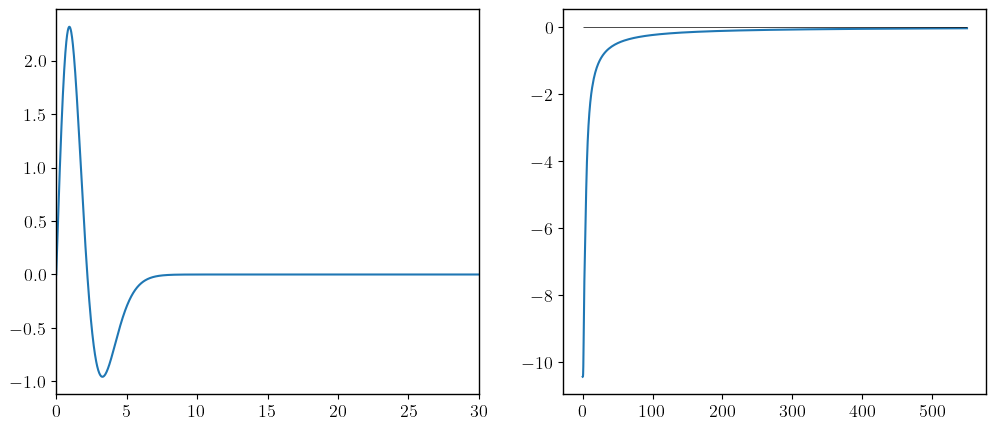

===>  4.2 [####################] 100%


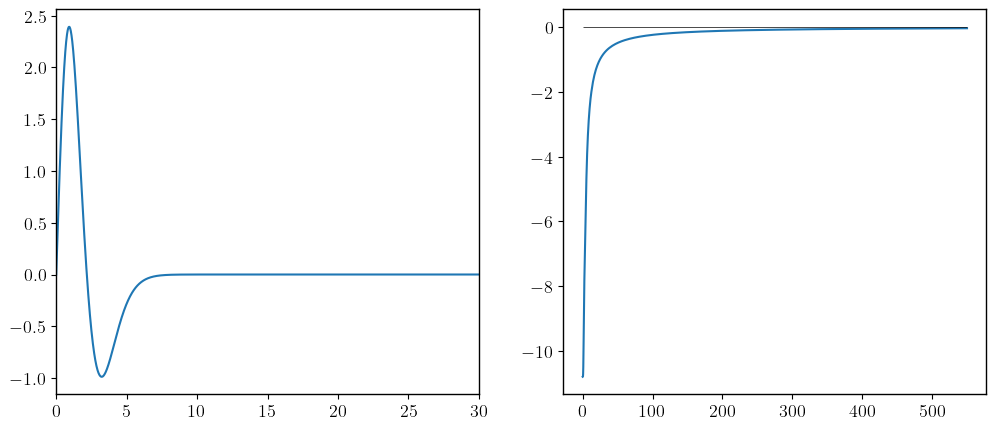

===>  4.4 [####################] 100%


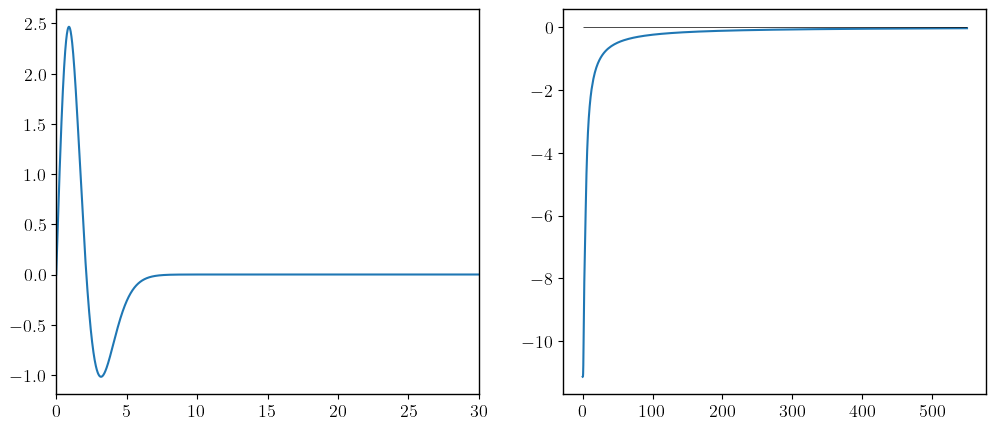

===>  4.6 [####################] 100%


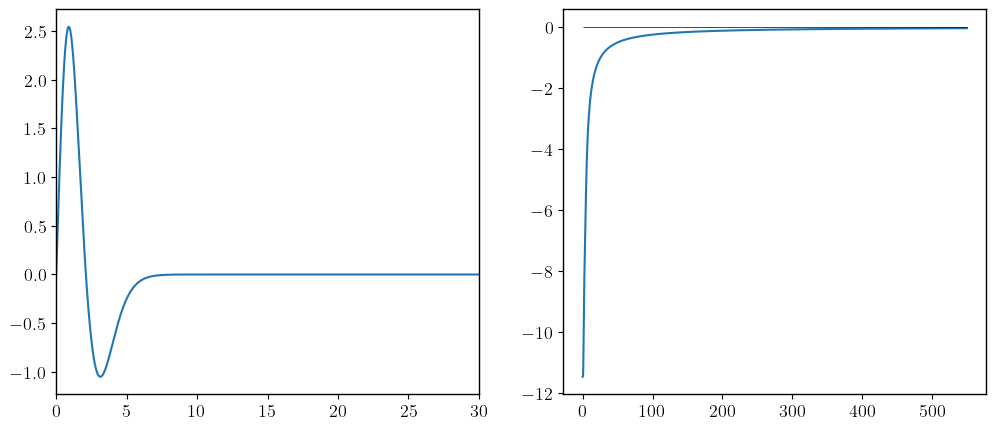

===>  4.8 [####################] 100%


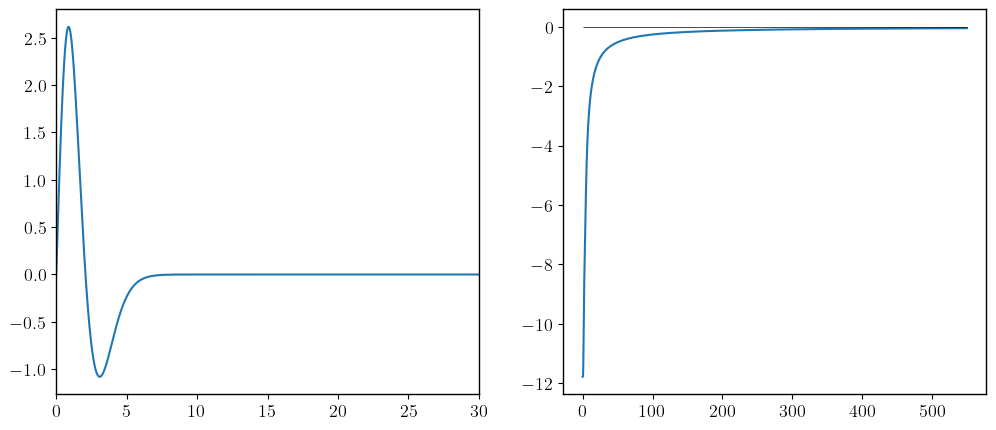

===>  5.0 [####################] 100%


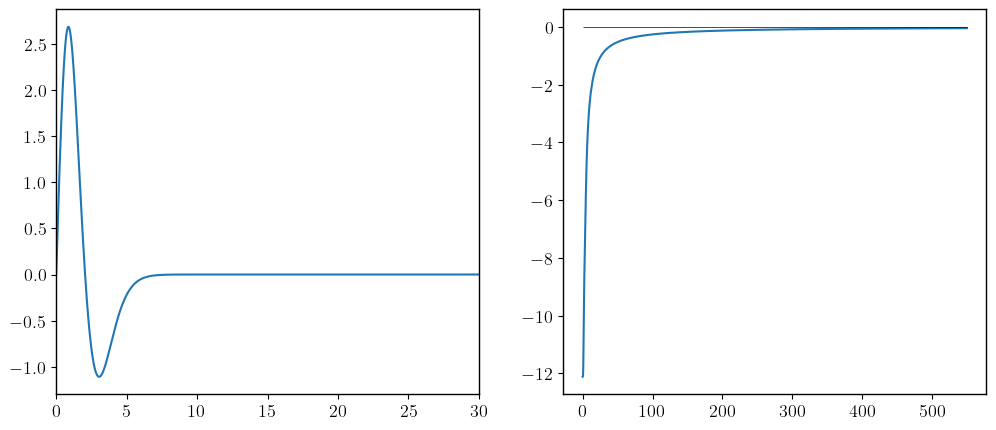

In [10]:
polariz = 'radial'
nodos = 1

full_data = []
for data in confidataEx:
    Ei, rDnew, sDnew, dsDnew, uDnew, duDnew = data
    print('===> ', sDnew[0])

    datFunc = [
        [interp1d(rDnew, rDnew * sDnew)],
        [interp1d(rDnew, uDnew)]
        ]
    
    rMax = 200*(nodos+1) + 150
    Nptos = int(3*rMax/4) * 2

    Jval = [0, 1, 2, 3]
    lamV_list = [[0., 1.], [0., -1.]]   # ln, ls
    alp = 0.0

    # Graphing
    rad2 = np.linspace(0, rMax, 500000)
    fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 5.),
                       sharex=False, sharey=False,
                       gridspec_kw=dict(hspace=0, wspace=.2))

    ax[0].plot(rad2, datFunc[0][0](rad2))
    ax[1].plot(rad2, Ei - datFunc[1][0](rad2))
    ax[1].hlines(0, 0, rMax, color='black', lw=0.5)
    ax[0].set_xlim(0, 30)
    #ax[0].set_ylim(-1, 1)
    # ax[0].set_yscale('log')
    plt.show()

    lambdaVal_s1, dataExtra_s1 = [], []
    for i in range(len(lamV_list)):
        lamV = lamV_list[i]
        lambdaVal, dataExtra = sp.LamJval(datFunc, rMax, lamV, alp, polariz, 
                Nptos=Nptos, Jval=Jval, info=False, fplot=False, real=False)
        lambdaVal_s1.append(lambdaVal)
        dataExtra_s1.append(dataExtra)
    
    full_data.append([sDnew[0], lambdaVal_s1, dataExtra_s1])

In [11]:
full_data_real = []
for data in full_data:
    s0, lambdaVal_s1, dataExtra_s1 = data
    print(s0, '/n', '#'*50)
    real_eigVal_s1LsP_list = []
    for i in range(len(lamV_list)):
        real_eigVal_s1LsP = []
        for ind, [Jval, data] in enumerate(dataExtra_s1[i]):
            rdis, eingVal, eigVect = data
            print('Jval = %d'%Jval)
            ind = np.abs(np.real(eingVal)) >= 1e-08 # filtrando los autovalores reales
            print(eingVal[ind])
            real_eigVal_s1LsP.append([Jval, eingVal[ind]])
        print('#'*50)
        real_eigVal_s1LsP_list.append([lamV_list[i], real_eigVal_s1LsP])

    full_data_real.append([s0, real_eigVal_s1LsP_list])


0.001 /n ##################################################
Jval = 0
[-3.40563667e-05+7.21685998e-15j  3.40563667e-05+8.68450602e-15j
  1.62886272e-03+8.78433143e-03j -1.62886272e-03+8.78433143e-03j
 -1.62886272e-03-8.78433143e-03j  1.62886272e-03-8.78433143e-03j]
Jval = 1
[-0.00015489-0.00275936j  0.00015489-0.00275936j -0.00015489+0.00275936j
  0.00015489+0.00275936j -0.00043949-0.01273662j  0.00043949-0.01273662j
  0.00043949+0.01273662j -0.00043949+0.01273662j]
Jval = 2
[ 0.00126314+5.31199875e-14j -0.00126314+5.31148476e-14j]
Jval = 3
[-0.00051509-0.0025853j  0.00051509-0.0025853j -0.00051509+0.0025853j
  0.00051509+0.0025853j]
##################################################
Jval = 0
[-3.40563667e-05+7.21685998e-15j  3.40563667e-05+8.68450602e-15j
  1.62886272e-03+8.78433143e-03j -1.62886272e-03+8.78433143e-03j
 -1.62886272e-03-8.78433143e-03j  1.62886272e-03-8.78433143e-03j]
Jval = 1
[-7.98394940e-07-4.00191316e-15j  7.98394940e-07-3.99678439e-15j
  1.50348600e-04-2.75445470e-

In [12]:
np.save("Real_Eingevalues_rad_polarization_Lsn1", np.array(full_data_real, dtype=object))

### Test

In [ ]:
# s01 = np.load("background_data_profiles_free_case/sigma_0_1_rad.npy", allow_pickle=True)
#Ei1, rDnew1, sDnew1, dsDnew1, uDnew1, duDnew1 = s01

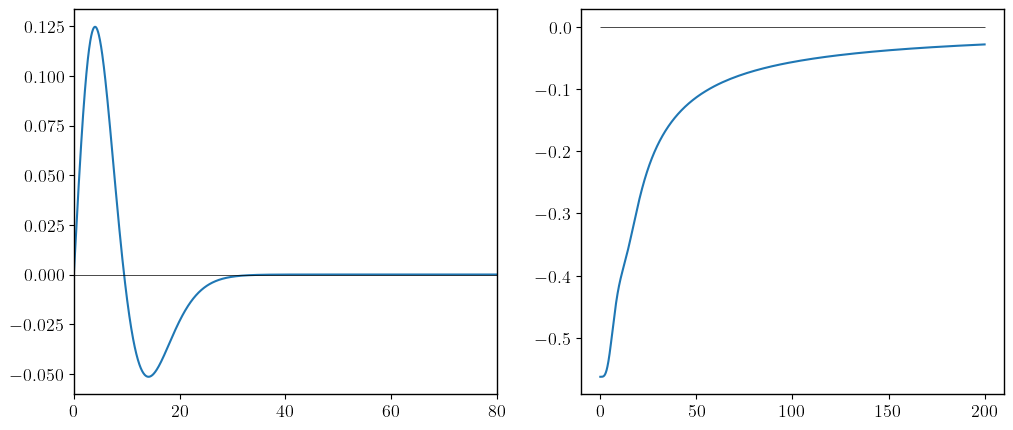

In [15]:
Ei, rDnew, sDnew, dsDnew, uDnew, duDnew = confidataEx[2]

polariz = 'radial'
datFunc = [
    [interp1d(rDnew, rDnew * sDnew)],
    [interp1d(rDnew, uDnew)],
]

nodos = 0
rMax = 200*(nodos+1) # - 30
Nptos = int(3*rMax/4) + 30

Jval = [0, 1, 2, 3]
lamV_list = [[0, 0], [0., 1.], [0., -1.]]   # ln, ls
alp = 0

# Graphing
rad2 = np.linspace(0, rMax, 500000)
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 5.),
                       sharex=False, sharey=False,
                       gridspec_kw=dict(hspace=0, wspace=.2))

ax[0].plot(rad2, datFunc[0][0](rad2))
ax[1].plot(rad2, Ei - datFunc[1][0](rad2))
ax[1].hlines(0, 0, rMax, color='black', lw=0.5)
ax[0].set_xlim(0, 80)
ax[0].hlines(0, 0, rMax, color='black', lw=0.5)
#ax[0].set_yscale('log')
#ax[0].set_ylim(-1, 1)
plt.show()

lambdaVal_s1, dataExtra_s1 = [], []
for i in range(len(lamV_list)):
    lamV = lamV_list[i]
    lambdaVal, dataExtra = sp.LamJval(datFunc, rMax, lamV, alp, polariz, 
            Nptos=Nptos, Jval=Jval, info=False, fplot=False, real=False)
    lambdaVal_s1.append(lambdaVal)
    dataExtra_s1.append(dataExtra)


In [16]:
real_eigVal_s1LsP_list = []
for i in range(len(lamV_list)):
    real_eigVal_s1LsP = []
    for ind, [Jval, data] in enumerate(dataExtra_s1[i]):
        rdis, eingVal, eigVect = data
        print('Jval = %d'%Jval)
        ind = np.abs(np.real(eingVal)) >= 1e-08 # filtrando los autovalores reales
        print(eingVal[ind])
        real_eigVal_s1LsP.append([Jval, eingVal[ind]])
    print('#'*50)
    real_eigVal_s1LsP_list.append([lamV_list[i], real_eigVal_s1LsP])


Jval = 0
[-0.00054875-6.61640476e-15j  0.00054875+1.08880404e-14j
  0.02210653+1.19221373e-01j -0.02210653+1.19221373e-01j
 -0.02210653-1.19221373e-01j  0.02210653-1.19221373e-01j]
Jval = 1
[ 0.0020737 +0.03741684j -0.0020737 +0.03741684j  0.0020737 -0.03741684j
 -0.0020737 -0.03741684j -0.00599509-0.17311527j  0.00599509-0.17311527j
  0.00599509+0.17311527j -0.00599509+0.17311527j]
Jval = 2
[ 0.0167131+4.35191376e-16j -0.0167131+3.85899727e-16j]
Jval = 3
[ 0.00702929+0.03512694j -0.00702929+0.03512694j  0.00702929-0.03512694j
 -0.00702929-0.03512694j]
##################################################
Jval = 0
[-0.00054875-6.61640476e-15j  0.00054875+1.08880404e-14j
 -0.00121854-4.01678199e-02j  0.00121854-4.01678199e-02j
 -0.00121854+4.01678199e-02j  0.00121854+4.01678199e-02j
  0.00121854+4.01678199e-02j -0.00121854+4.01678199e-02j
 -0.00121854-4.01678199e-02j  0.00121854-4.01678199e-02j
  0.02210653+1.19221373e-01j -0.02210653+1.19221373e-01j
 -0.02210653-1.19221373e-01j  0.0221065